# DQN with CartPole-v2 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `CartPole-v1` using the Gymnassium API for envrionment.

CartPole has a `Box(4,)` **observation space** and a `Discrete(2)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [8]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra

## Reading the `config` file

In [9]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_cartpole', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'CartPole-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {},
   'state': {'min': [-4.8, -10, -0.41887903, -10],
    'max': [4.8, 10, 0.41887903, 10]}},
  'clip': {'action': False,
   'state': {'min': [None, -100, None, -100], 'max': [None, 100, None, 100]}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 64,
  'nn_learning_rate': 0.0005,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.99991,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 3},
 'training': {'no_episodes': 1500, 'target_network_update_steps': 1},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'hankel_rollout', 'kwargs': {'seed': 52}},
   {'name': 'q_matrix_dqn',
    'kwargs': {'state_discretisation': [8, 8, 8, 8], 'batch_size': 64}}]}}

## Creating the Envrionment

In [10]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
    clip=env_cfg["clip"],
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 4 n_actions: 2


## Creating the Agent

In [11]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [12]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
)

## Analysis (Low Rank)

In [13]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs}. Resolve `name` to its callable and pre-bind
# the config-supplied `kwargs` with functools.partial, leaving only the runtime
# args (agent, env) for the training loop to inject at call time.
analysis["methods"] = [
    partial(analysis_methods[m["name"]], **m.get("kwargs", {}))
    for m in analysis["methods"]
]
analysis

{'ep_freq': 50,
 'methods': [functools.partial(<function hankel_rollout at 0x121e4c540>, seed=52),
  functools.partial(<function q_matrix_dqn at 0x121e4c400>, state_discretisation=[8, 8, 8, 8], batch_size=64)]}

## Agent Training 

  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 3.1
**************************** DEBUG INFO START **********************************
Episode 0 is complete with reward 31.0
Replay_buffer_length 31
Epsilon for epsilon-greedy is 0.9972137632252072
**************************** DEBUG INFO END **********************************
Hankel Value Function


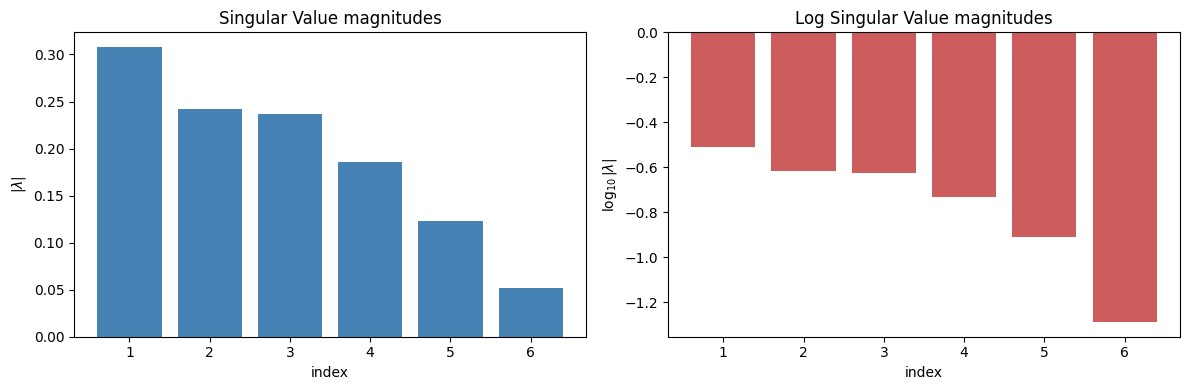

Q-function


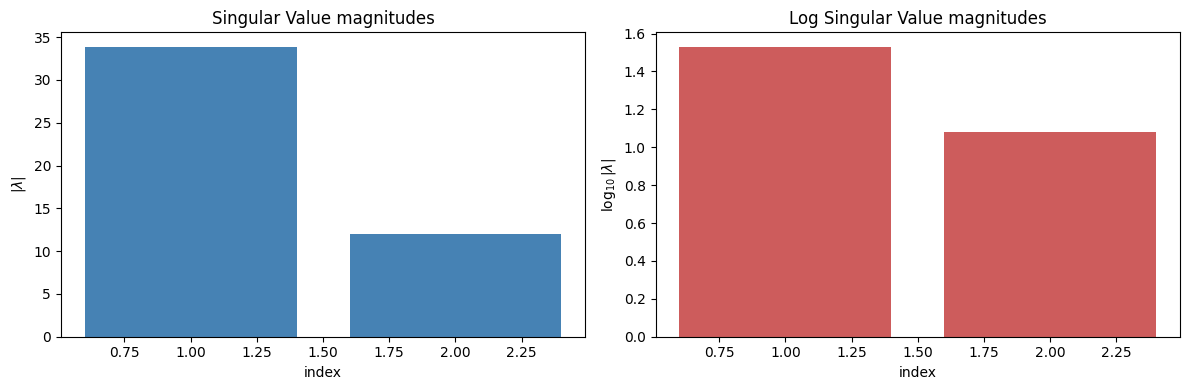

  0%|          | 1/1500 [00:00<07:08,  3.50it/s]

**************************** DEBUG INFO START **********************************
Episode 1 is complete with reward 0.0
Replay_buffer_length 32
Epsilon for epsilon-greedy is 0.9960476529540226
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 2 is complete with reward 17.0
Replay_buffer_length 49
Epsilon for epsilon-greedy is 0.9945247967974916
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 3 is complete with reward 17.0
Replay_buffer_length 66
Epsilon for epsilon-greedy is 0.9930042689340564
**************************** DEBUG INFO END **********************************


  0%|          | 6/1500 [00:00<01:22, 18.14it/s]

**************************** DEBUG INFO START **********************************
Episode 4 is complete with reward 16.0
Replay_buffer_length 82
Epsilon for epsilon-greedy is 0.9915753075816744
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 5 is complete with reward 35.0
Replay_buffer_length 117
Epsilon for epsilon-greedy is 0.9884566195322825
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 6 is complete with reward 32.0
Replay_buffer_length 149
Epsilon for epsilon-greedy is 0.9856138321195729
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 7 is complete with reward 13.0
Replay_buffer_length 162
Epsilon for epsilon-greedy is 0.98446

  1%|          | 10/1500 [00:00<01:00, 24.47it/s]

...

**************************** DEBUG INFO START **********************************
Episode 41 is complete with reward 14.0
Replay_buffer_length 950
Epsilon for epsilon-greedy is 0.9170586077021328
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 42 is complete with reward 15.0
Replay_buffer_length 965
Epsilon for epsilon-greedy is 0.9158213582359787
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 43 is complete with reward 9.0
Replay_buffer_length 974
Epsilon for epsilon-greedy is 0.9150798099332416
**************************** DEBUG INFO END **********************************


  3%|▎         | 46/1500 [00:02<01:07, 21.51it/s]

**************************** DEBUG INFO START **********************************
Episode 44 is complete with reward 13.0
Replay_buffer_length 987
Epsilon for epsilon-greedy is 0.9140097445122972
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 45 is complete with reward 14.0
Replay_buffer_length 1001
Epsilon for epsilon-greedy is 0.9128587657083158
**************************** DEBUG INFO END **********************************


  3%|▎         | 49/1500 [00:02<01:06, 21.77it/s]

**************************** DEBUG INFO START **********************************
Episode 46 is complete with reward 18.0
Replay_buffer_length 1019
Epsilon for epsilon-greedy is 0.9113810652708925
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 47 is complete with reward 14.0
Replay_buffer_length 1033
Epsilon for epsilon-greedy is 0.9102333966658533
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 48 is complete with reward 18.0
Replay_buffer_length 1051
Epsilon for epsilon-greedy is 0.9087599460742205
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 49 is complete with reward 20.0
Replay_buffer_length 1071
Epsilon for epsilon-greedy i

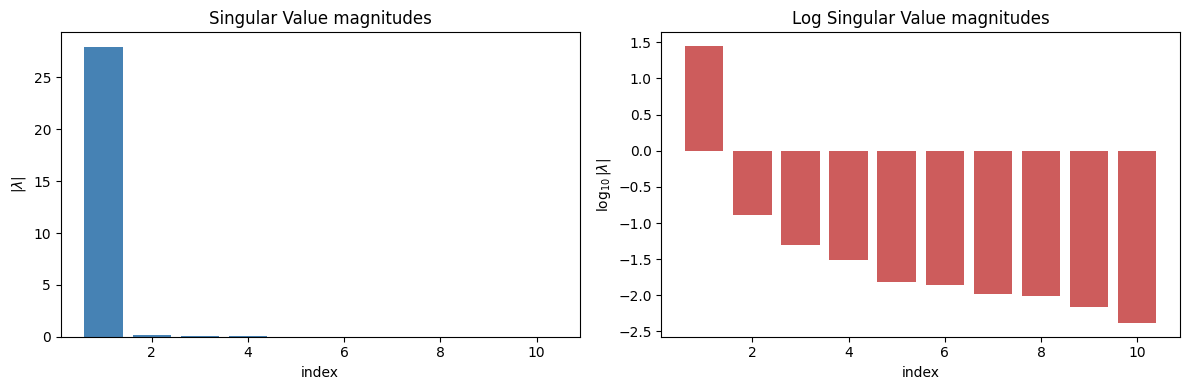

Q-function


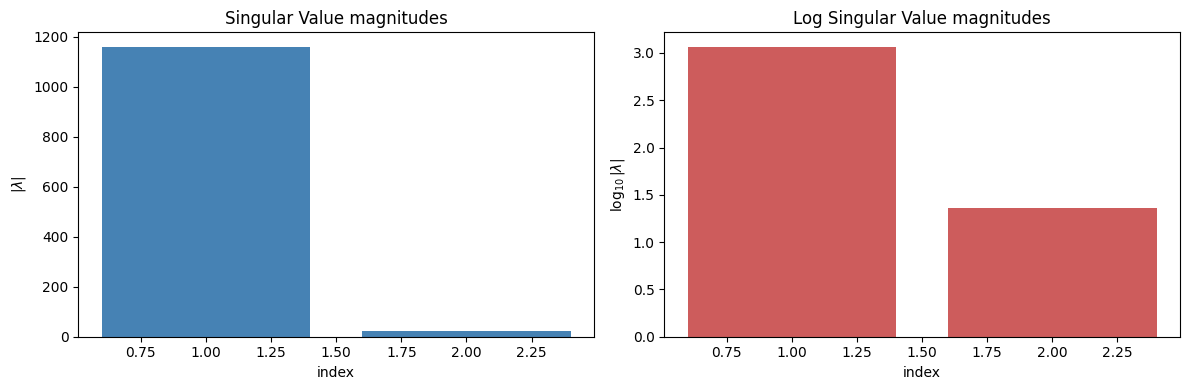

  3%|▎         | 52/1500 [00:02<01:42, 14.19it/s]

**************************** DEBUG INFO START **********************************
Episode 51 is complete with reward 0.0
Replay_buffer_length 1085
Epsilon for epsilon-greedy is 0.9044352890262576
**************************** DEBUG INFO END **********************************


  4%|▎         | 54/1500 [00:02<01:37, 14.88it/s]

**************************** DEBUG INFO START **********************************
Episode 52 is complete with reward 26.0
Replay_buffer_length 1111
Epsilon for epsilon-greedy is 0.9023212896624536
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 53 is complete with reward 21.0
Replay_buffer_length 1132
Epsilon for epsilon-greedy is 0.9006174363989953
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 54 is complete with reward 18.0
Replay_buffer_length 1150
Epsilon for epsilon-greedy is 0.8991595517516531
**************************** DEBUG INFO END **********************************


  4%|▎         | 56/1500 [00:02<01:38, 14.62it/s]

...

episode 90 avg_rewarg: 24.5
**************************** DEBUG INFO START **********************************
Episode 90 is complete with reward 13.0
Replay_buffer_length 2028
Epsilon for epsilon-greedy is 0.8308397526787299
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 91 is complete with reward 9.0
Replay_buffer_length 2037
Epsilon for epsilon-greedy is 0.8301670147010612
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 92 is complete with reward 19.0
Replay_buffer_length 2056
Epsilon for epsilon-greedy is 0.8287485783840342
**************************** DEBUG INFO END **********************************


  6%|▋         | 95/1500 [00:06<02:22,  9.89it/s]

**************************** DEBUG INFO START **********************************
Episode 93 is complete with reward 74.0
Replay_buffer_length 2130
Epsilon for epsilon-greedy is 0.8232472051948333
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 94 is complete with reward 15.0
Replay_buffer_length 2145
Epsilon for epsilon-greedy is 0.8221365213665746
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 95 is complete with reward 23.0
Replay_buffer_length 2168
Epsilon for epsilon-greedy is 0.820436382510769
**************************** DEBUG INFO END **********************************


  7%|▋         | 99/1500 [00:06<02:17, 10.22it/s]

**************************** DEBUG INFO START **********************************
Episode 96 is complete with reward 31.0
Replay_buffer_length 2199
Epsilon for epsilon-greedy is 0.8181504524904397
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 97 is complete with reward 12.0
Replay_buffer_length 2211
Epsilon for epsilon-greedy is 0.8172672872537933
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 98 is complete with reward 12.0
Replay_buffer_length 2223
Epsilon for epsilon-greedy is 0.8163850753636038
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 99 is complete with reward 17.0
Replay_buffer_length 2240
Epsilon for epsilon-greedy i

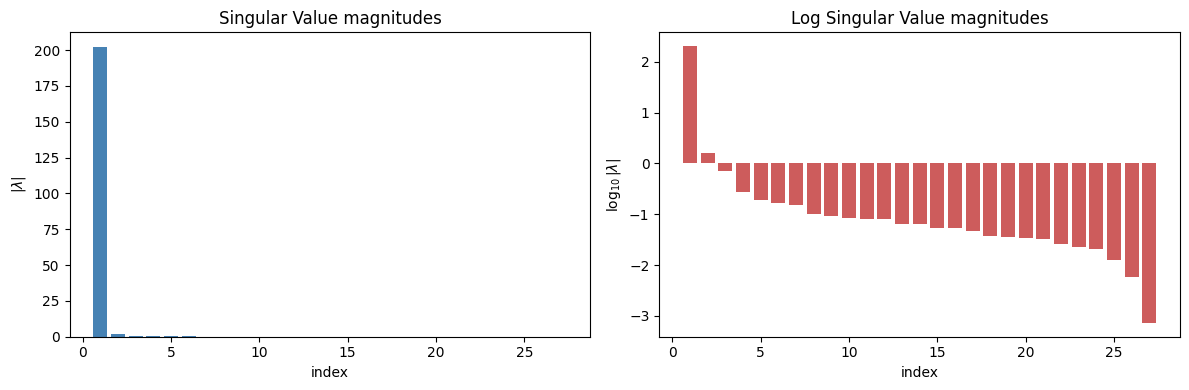

Q-function


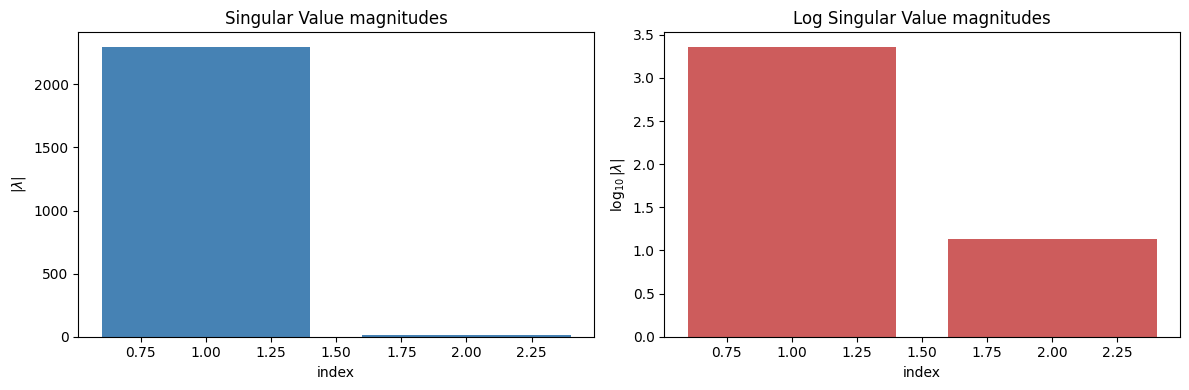

  7%|▋         | 103/1500 [00:07<03:08,  7.40it/s]

**************************** DEBUG INFO START **********************************
Episode 101 is complete with reward 0.0
Replay_buffer_length 2255
Epsilon for epsilon-greedy is 0.8101632782701466
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 102 is complete with reward 12.0
Replay_buffer_length 2267
Epsilon for epsilon-greedy is 0.8092887349129955
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 103 is complete with reward 10.0
Replay_buffer_length 2277
Epsilon for epsilon-greedy is 0.8085606699665321
**************************** DEBUG INFO END **********************************


  7%|▋         | 107/1500 [00:07<02:22,  9.77it/s]

**************************** DEBUG INFO START **********************************
Episode 104 is complete with reward 26.0
Replay_buffer_length 2303
Epsilon for epsilon-greedy is 0.80667076500302
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 105 is complete with reward 10.0
Replay_buffer_length 2313
Epsilon for epsilon-greedy is 0.8059450552754546
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 106 is complete with reward 15.0
Replay_buffer_length 2328
Epsilon for epsilon-greedy is 0.8048577146398461
**************************** DEBUG INFO END **********************************


  7%|▋         | 111/1500 [00:07<02:01, 11.47it/s]

...

**************************** DEBUG INFO START **********************************
Episode 144 is complete with reward 80.0
Replay_buffer_length 3469
Epsilon for epsilon-greedy is 0.726305618574274
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 145 is complete with reward 71.0
Replay_buffer_length 3540
Epsilon for epsilon-greedy is 0.7216791148982249
**************************** DEBUG INFO END **********************************


 10%|▉         | 148/1500 [00:12<03:46,  5.96it/s]

**************************** DEBUG INFO START **********************************
Episode 146 is complete with reward 87.0
Replay_buffer_length 3627
Epsilon for epsilon-greedy is 0.7160501801621132
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 147 is complete with reward 71.0
Replay_buffer_length 3698
Epsilon for epsilon-greedy is 0.7114890027375763
**************************** DEBUG INFO END **********************************


 10%|█         | 150/1500 [00:12<03:16,  6.86it/s]

**************************** DEBUG INFO START **********************************
Episode 148 is complete with reward 26.0
Replay_buffer_length 3724
Epsilon for epsilon-greedy is 0.709825990118111
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 149 is complete with reward 29.0
Replay_buffer_length 3753
Epsilon for epsilon-greedy is 0.7079756767279485
**************************** DEBUG INFO END **********************************
episode 150 avg_rewarg: 49.7
**************************** DEBUG INFO START **********************************
Episode 150 is complete with reward 33.0
Replay_buffer_length 3786
Epsilon for epsilon-greedy is 0.7058760140244204
**************************** DEBUG INFO END **********************************
Hankel Value Function


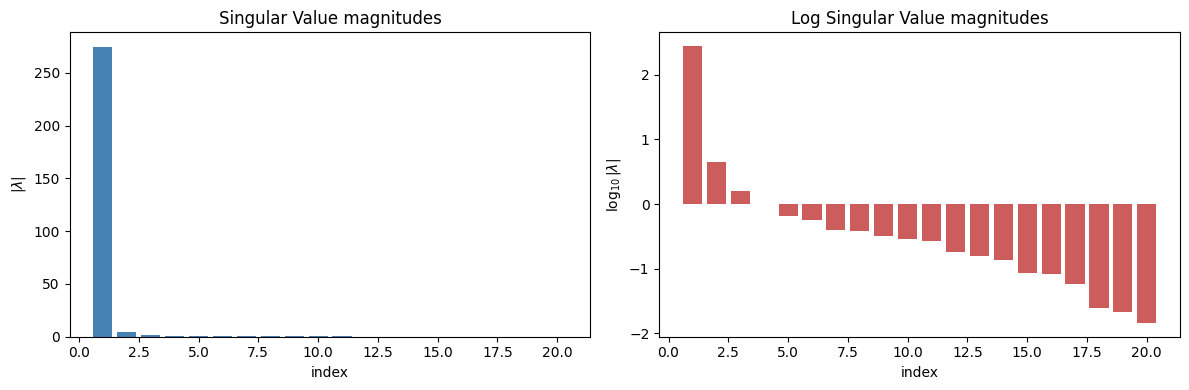

Q-function


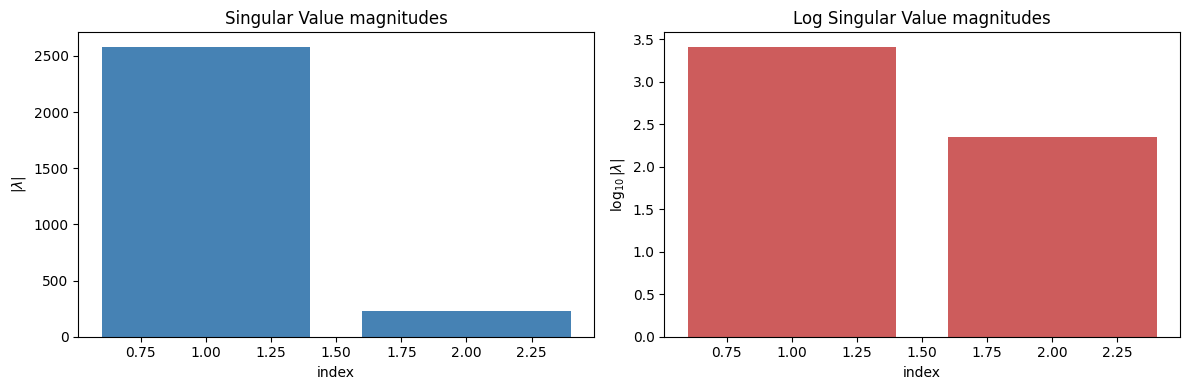

 10%|█         | 153/1500 [00:13<04:22,  5.12it/s]

**************************** DEBUG INFO START **********************************
Episode 151 is complete with reward 0.0
Replay_buffer_length 3787
Epsilon for epsilon-greedy is 0.7032760144803798
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 152 is complete with reward 69.0
Replay_buffer_length 3856
Epsilon for epsilon-greedy is 0.6989220076813047
**************************** DEBUG INFO END **********************************


 10%|█         | 155/1500 [00:13<03:54,  5.73it/s]

**************************** DEBUG INFO START **********************************
Episode 153 is complete with reward 60.0
Replay_buffer_length 3916
Epsilon for epsilon-greedy is 0.6951578318714129
**************************** DEBUG INFO END **********************************
**************************** DEBUG INFO START **********************************
Episode 154 is complete with reward 22.0
Replay_buffer_length 3938
Epsilon for epsilon-greedy is 0.6937827192940338
**************************** DEBUG INFO END **********************************


 10%|█         | 156/1500 [00:13<04:12,  5.32it/s]

...

**************************** DEBUG INFO START **********************************
Episode 197 is complete with reward 235.0
Replay_buffer_length 6659
Epsilon for epsilon-greedy is 0.5430806340198974
**************************** DEBUG INFO END **********************************


 13%|█▎        | 199/1500 [00:23<07:18,  2.97it/s]

**************************** DEBUG INFO START **********************************
Episode 198 is complete with reward 55.0
Replay_buffer_length 6714
Epsilon for epsilon-greedy is 0.5403989069524567
**************************** DEBUG INFO END **********************************


 13%|█▎        | 200/1500 [00:24<08:17,  2.61it/s]

**************************** DEBUG INFO START **********************************
Episode 199 is complete with reward 205.0
Replay_buffer_length 6919
Epsilon for epsilon-greedy is 0.530519520141785
**************************** DEBUG INFO END **********************************
episode 200 avg_rewarg: 98.6
**************************** DEBUG INFO START **********************************
Episode 200 is complete with reward 97.0
Replay_buffer_length 7016
Epsilon for epsilon-greedy is 0.525908035630088
**************************** DEBUG INFO END **********************************
Hankel Value Function


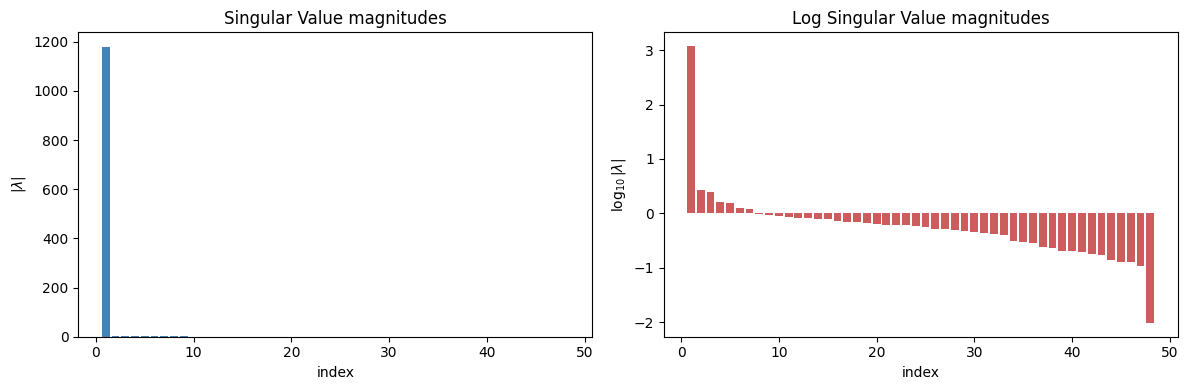

Q-function


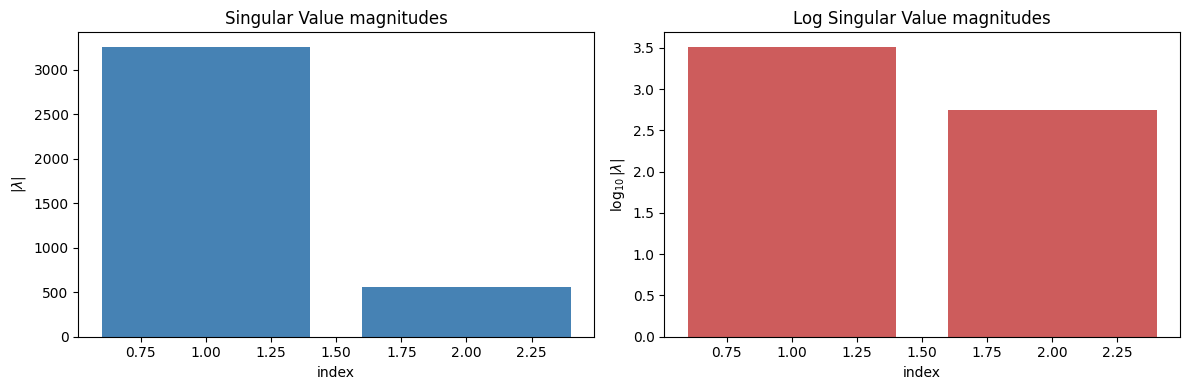

 13%|█▎        | 202/1500 [00:24<08:16,  2.61it/s]

**************************** DEBUG INFO START **********************************
Episode 201 is complete with reward 0.0
Replay_buffer_length 7017
Epsilon for epsilon-greedy is 0.521336635957109
**************************** DEBUG INFO END **********************************


 14%|█▎        | 203/1500 [00:25<08:15,  2.62it/s]

**************************** DEBUG INFO START **********************************
Episode 202 is complete with reward 134.0
Replay_buffer_length 7151
Epsilon for epsilon-greedy is 0.5150867971615825
**************************** DEBUG INFO END **********************************


 14%|█▎        | 204/1500 [00:25<08:48,  2.45it/s]

...

**************************** DEBUG INFO START **********************************
Episode 247 is complete with reward 151.0
Replay_buffer_length 16819
Epsilon for epsilon-greedy is 0.21576206872959636
**************************** DEBUG INFO END **********************************


 17%|█▋        | 249/1500 [01:00<19:34,  1.07it/s]

**************************** DEBUG INFO START **********************************
Episode 248 is complete with reward 180.0
Replay_buffer_length 16999
Epsilon for epsilon-greedy is 0.21229472847341088
**************************** DEBUG INFO END **********************************


 17%|█▋        | 250/1500 [01:01<21:29,  1.03s/it]

**************************** DEBUG INFO START **********************************
Episode 249 is complete with reward 272.0
Replay_buffer_length 17271
Epsilon for epsilon-greedy is 0.20716062036749439
**************************** DEBUG INFO END **********************************
episode 250 avg_rewarg: 224.2
**************************** DEBUG INFO START **********************************
Episode 250 is complete with reward 175.0
Replay_buffer_length 17446
Epsilon for epsilon-greedy is 0.20392325608199982
**************************** DEBUG INFO END **********************************
Hankel Value Function


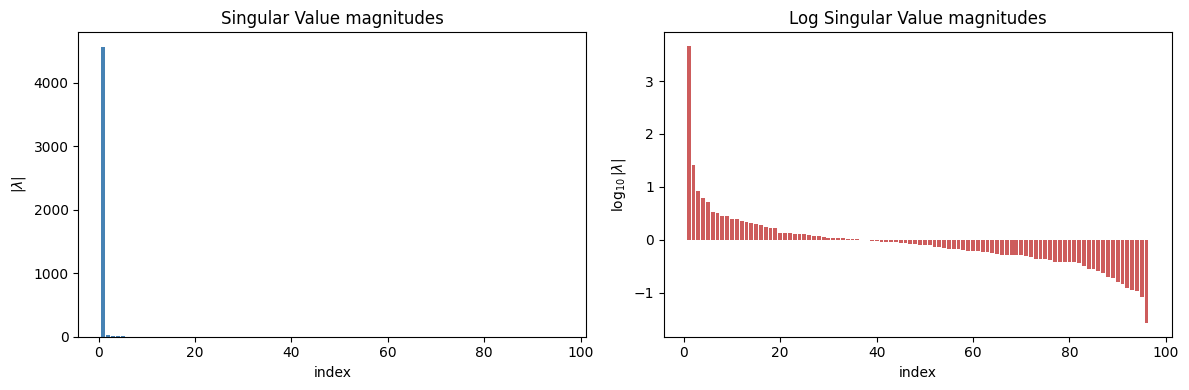

Q-function


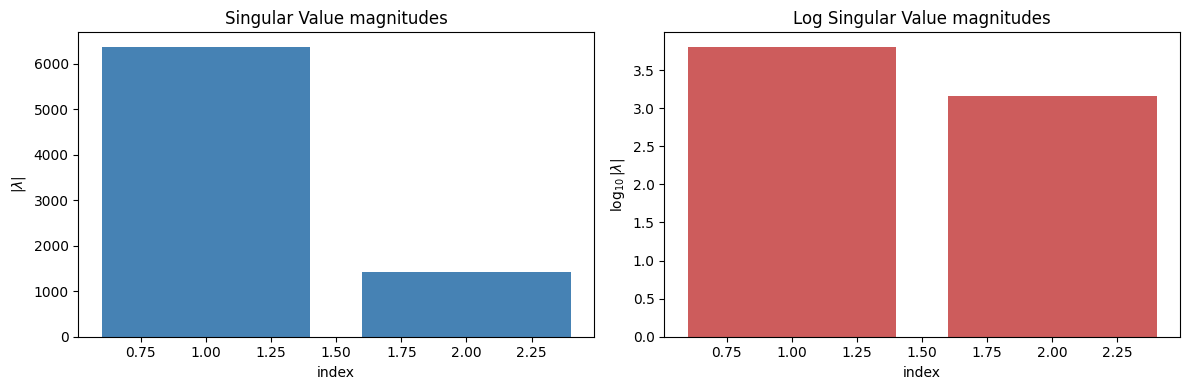

 17%|█▋        | 252/1500 [01:04<22:12,  1.07s/it]

**************************** DEBUG INFO START **********************************
Episode 251 is complete with reward 0.0
Replay_buffer_length 17447
Epsilon for epsilon-greedy is 0.20042957732088199
**************************** DEBUG INFO END **********************************


 17%|█▋        | 253/1500 [01:05<22:14,  1.07s/it]

**************************** DEBUG INFO START **********************************
Episode 252 is complete with reward 213.0
Replay_buffer_length 17660
Epsilon for epsilon-greedy is 0.19662376631206724
**************************** DEBUG INFO END **********************************


 17%|█▋        | 254/1500 [01:06<20:55,  1.01s/it]

...

**************************** DEBUG INFO START **********************************
Episode 297 is complete with reward 258.0
Replay_buffer_length 28939
Epsilon for epsilon-greedy is 0.07124583806704832
**************************** DEBUG INFO END **********************************


 20%|█▉        | 299/1500 [02:01<28:59,  1.45s/it]

**************************** DEBUG INFO START **********************************
Episode 298 is complete with reward 201.0
Replay_buffer_length 29140
Epsilon for epsilon-greedy is 0.06996853144950178
**************************** DEBUG INFO END **********************************


 20%|██        | 300/1500 [02:02<28:13,  1.41s/it]

**************************** DEBUG INFO START **********************************
Episode 299 is complete with reward 270.0
Replay_buffer_length 29410
Epsilon for epsilon-greedy is 0.0682887129990597
**************************** DEBUG INFO END **********************************
episode 300 avg_rewarg: 272.4
**************************** DEBUG INFO START **********************************
Episode 300 is complete with reward 253.0
Replay_buffer_length 29663
Epsilon for epsilon-greedy is 0.06675127992297938
**************************** DEBUG INFO END **********************************
Hankel Value Function


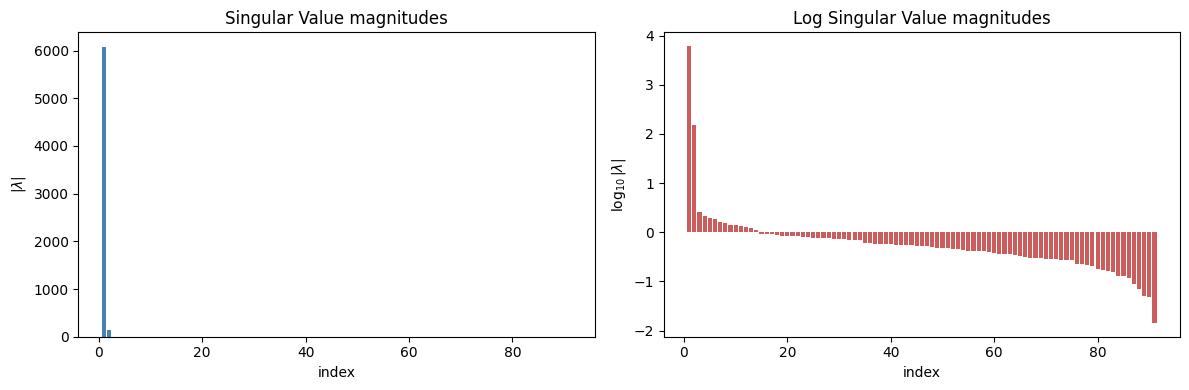

Q-function


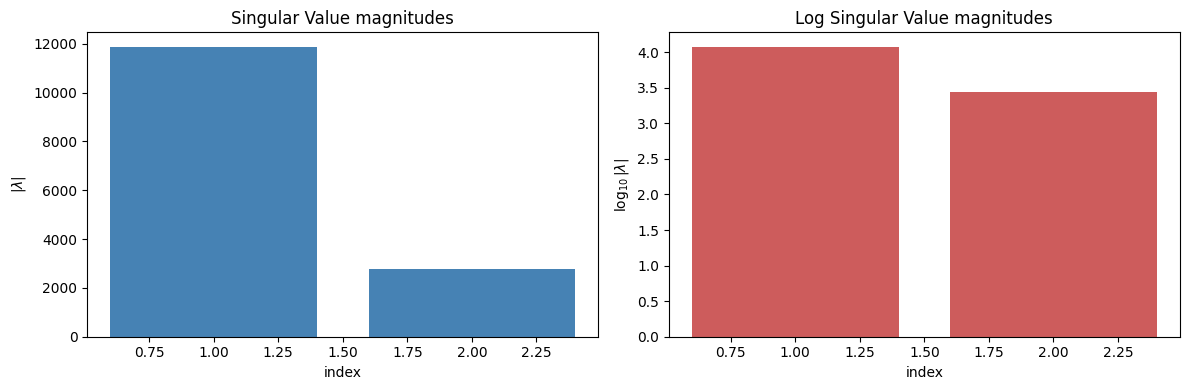

 20%|██        | 302/1500 [02:05<29:09,  1.46s/it]

**************************** DEBUG INFO START **********************************
Episode 301 is complete with reward 0.0
Replay_buffer_length 29664
Epsilon for epsilon-greedy is 0.06566675168919682
**************************** DEBUG INFO END **********************************


 20%|██        | 303/1500 [02:07<30:32,  1.53s/it]

**************************** DEBUG INFO START **********************************
Episode 302 is complete with reward 262.0
Replay_buffer_length 29926
Epsilon for epsilon-greedy is 0.06413637487114456
**************************** DEBUG INFO END **********************************


 20%|██        | 304/1500 [02:08<29:17,  1.47s/it]

...

**************************** DEBUG INFO START **********************************
Episode 347 is complete with reward 156.0
Replay_buffer_length 41776
Epsilon for epsilon-greedy is 0.022075395847913088
**************************** DEBUG INFO END **********************************


 23%|██▎       | 349/1500 [03:28<36:56,  1.93s/it]

**************************** DEBUG INFO START **********************************
Episode 348 is complete with reward 203.0
Replay_buffer_length 41979
Epsilon for epsilon-greedy is 0.021675722513889918
**************************** DEBUG INFO END **********************************


 23%|██▎       | 350/1500 [03:32<46:28,  2.42s/it]

**************************** DEBUG INFO START **********************************
Episode 349 is complete with reward 138.0
Replay_buffer_length 42117
Epsilon for epsilon-greedy is 0.02140816298413108
**************************** DEBUG INFO END **********************************
episode 350 avg_rewarg: 181.5
**************************** DEBUG INFO START **********************************
Episode 350 is complete with reward 146.0
Replay_buffer_length 42263
Epsilon for epsilon-greedy is 0.021128687322372875
**************************** DEBUG INFO END **********************************
Hankel Value Function


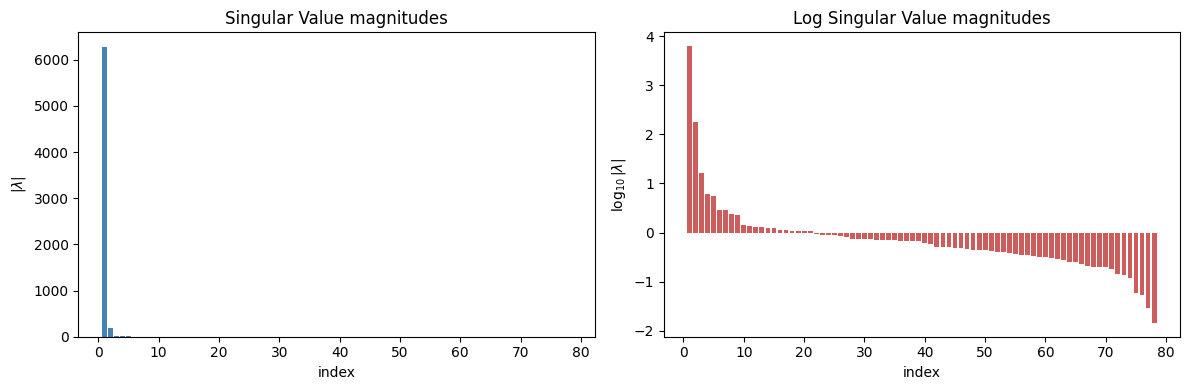

Q-function


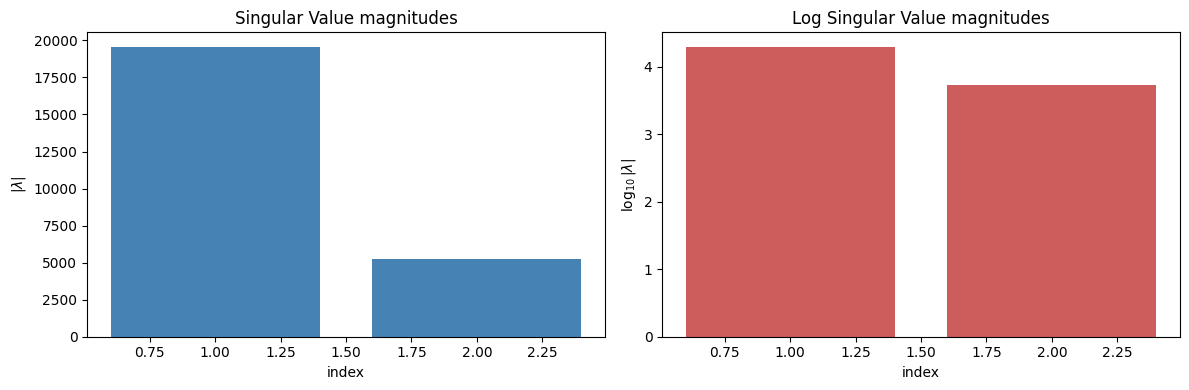

 23%|██▎       | 352/1500 [03:35<37:14,  1.95s/it]

**************************** DEBUG INFO START **********************************
Episode 351 is complete with reward 0.0
Replay_buffer_length 42264
Epsilon for epsilon-greedy is 0.02083410013711165
**************************** DEBUG INFO END **********************************


 24%|██▎       | 353/1500 [03:36<34:13,  1.79s/it]

**************************** DEBUG INFO START **********************************
Episode 352 is complete with reward 174.0
Replay_buffer_length 42438
Epsilon for epsilon-greedy is 0.020510365022829123
**************************** DEBUG INFO END **********************************


 24%|██▎       | 354/1500 [03:37<31:34,  1.65s/it]

...

**************************** DEBUG INFO START **********************************
Episode 397 is complete with reward 79.0
Replay_buffer_length 46554
Epsilon for epsilon-greedy is 0.014160744979603753
**************************** DEBUG INFO END **********************************


 27%|██▋       | 399/1500 [04:51<40:40,  2.22s/it]

**************************** DEBUG INFO START **********************************
Episode 398 is complete with reward 74.0
Replay_buffer_length 46628
Epsilon for epsilon-greedy is 0.01406674356011196
**************************** DEBUG INFO END **********************************


 27%|██▋       | 400/1500 [04:53<40:30,  2.21s/it]

**************************** DEBUG INFO START **********************************
Episode 399 is complete with reward 81.0
Replay_buffer_length 46709
Epsilon for epsilon-greedy is 0.013964565293782814
**************************** DEBUG INFO END **********************************
episode 400 avg_rewarg: 81.7
**************************** DEBUG INFO START **********************************
Episode 400 is complete with reward 103.0
Replay_buffer_length 46812
Epsilon for epsilon-greedy is 0.013835706159658175
**************************** DEBUG INFO END **********************************
Hankel Value Function


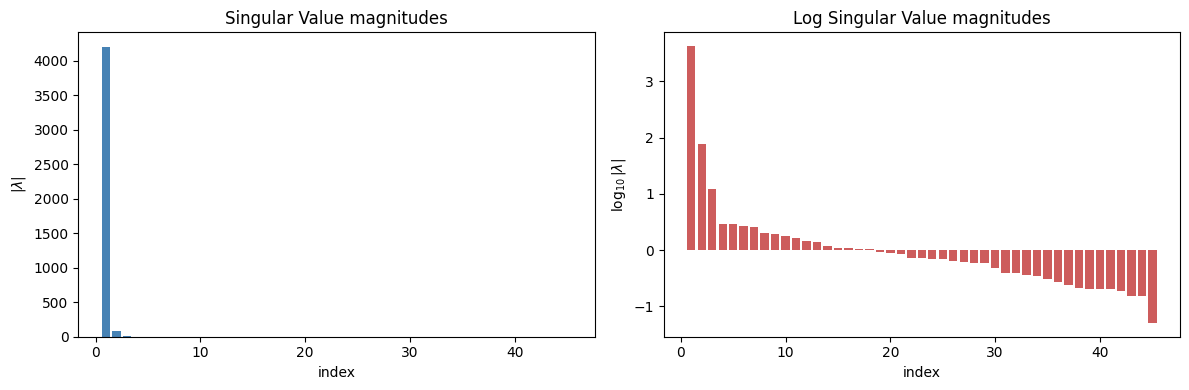

Q-function


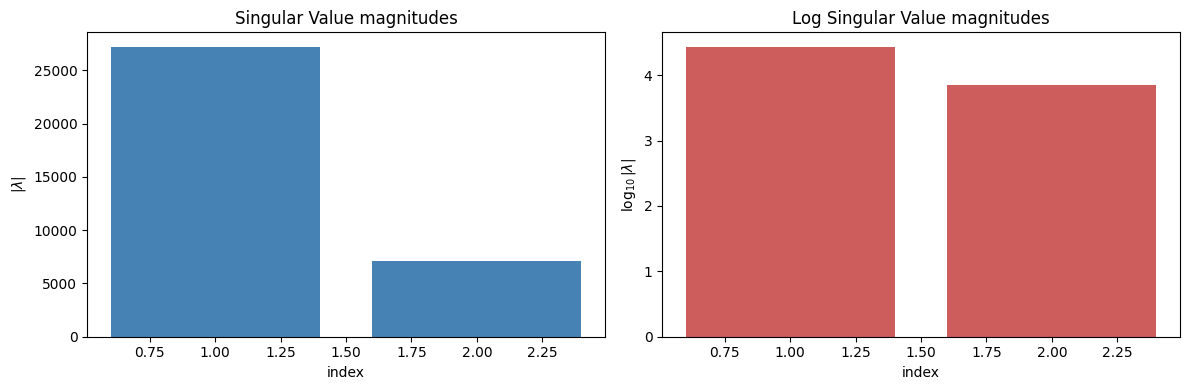

 27%|██▋       | 402/1500 [04:59<44:38,  2.44s/it]

**************************** DEBUG INFO START **********************************
Episode 401 is complete with reward 7.0
Replay_buffer_length 46820
Epsilon for epsilon-greedy is 0.013714206365530442
**************************** DEBUG INFO END **********************************


 27%|██▋       | 403/1500 [05:00<39:28,  2.16s/it]

**************************** DEBUG INFO START **********************************
Episode 402 is complete with reward 77.0
Replay_buffer_length 46897
Epsilon for epsilon-greedy is 0.013619491220224154
**************************** DEBUG INFO END **********************************


 27%|██▋       | 404/1500 [05:01<34:42,  1.90s/it]

...

**************************** DEBUG INFO START **********************************
Episode 447 is complete with reward 72.0
Replay_buffer_length 50651
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 30%|██▉       | 449/1500 [06:01<23:41,  1.35s/it]

**************************** DEBUG INFO START **********************************
Episode 448 is complete with reward 38.0
Replay_buffer_length 50689
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 30%|███       | 450/1500 [06:02<22:48,  1.30s/it]

**************************** DEBUG INFO START **********************************
Episode 449 is complete with reward 78.0
Replay_buffer_length 50767
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 450 avg_rewarg: 59.1
**************************** DEBUG INFO START **********************************
Episode 450 is complete with reward 66.0
Replay_buffer_length 50833
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


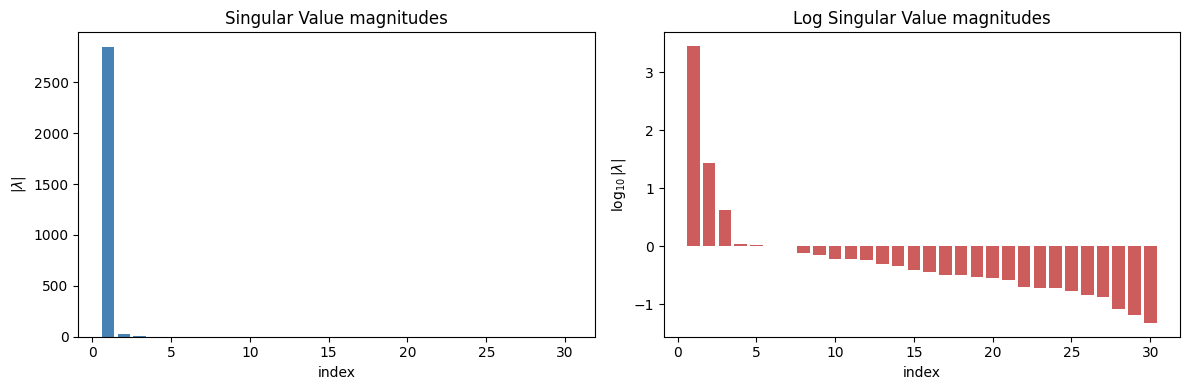

Q-function


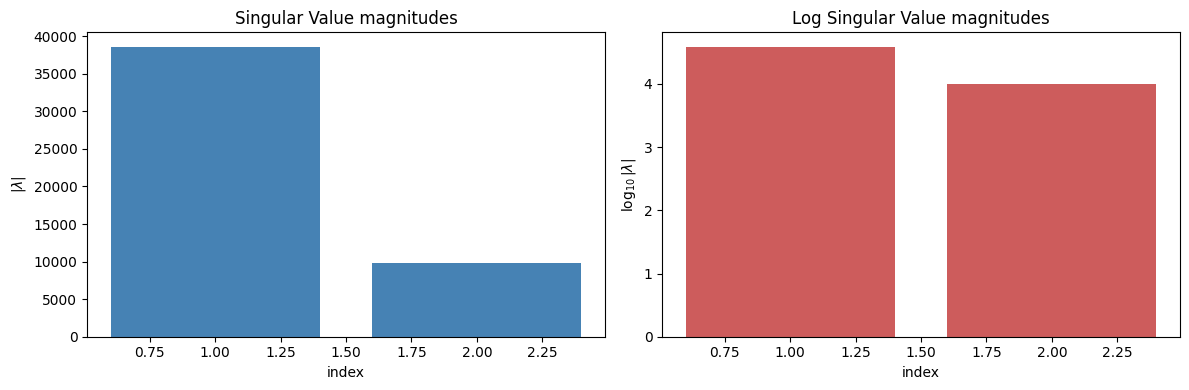

 30%|███       | 452/1500 [06:05<23:13,  1.33s/it]

**************************** DEBUG INFO START **********************************
Episode 451 is complete with reward 0.0
Replay_buffer_length 50834
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 30%|███       | 453/1500 [06:06<22:18,  1.28s/it]

**************************** DEBUG INFO START **********************************
Episode 452 is complete with reward 62.0
Replay_buffer_length 50896
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 30%|███       | 454/1500 [06:07<22:02,  1.26s/it]

...

**************************** DEBUG INFO START **********************************
Episode 497 is complete with reward 27.0
Replay_buffer_length 52350
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 33%|███▎      | 499/1500 [07:05<25:04,  1.50s/it]

**************************** DEBUG INFO START **********************************
Episode 498 is complete with reward 24.0
Replay_buffer_length 52374
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 33%|███▎      | 500/1500 [07:07<25:16,  1.52s/it]

**************************** DEBUG INFO START **********************************
Episode 499 is complete with reward 25.0
Replay_buffer_length 52399
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 500 avg_rewarg: 26.2
**************************** DEBUG INFO START **********************************
Episode 500 is complete with reward 25.0
Replay_buffer_length 52424
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


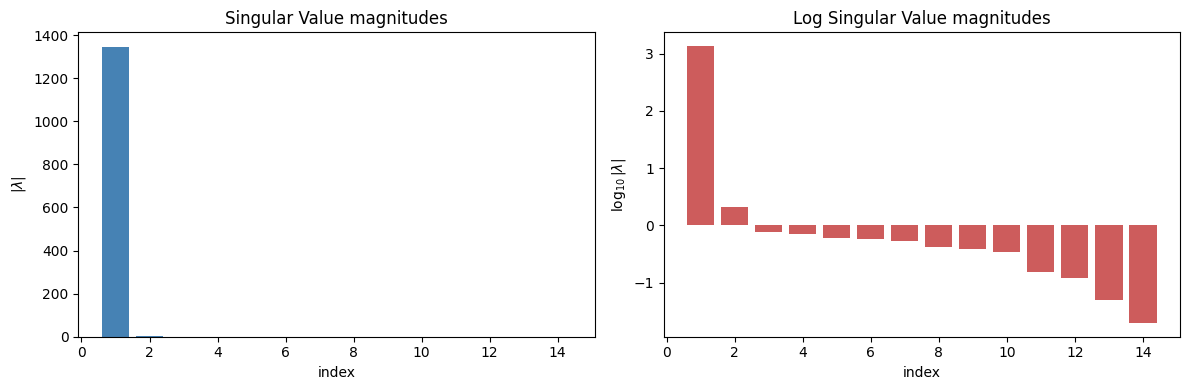

Q-function


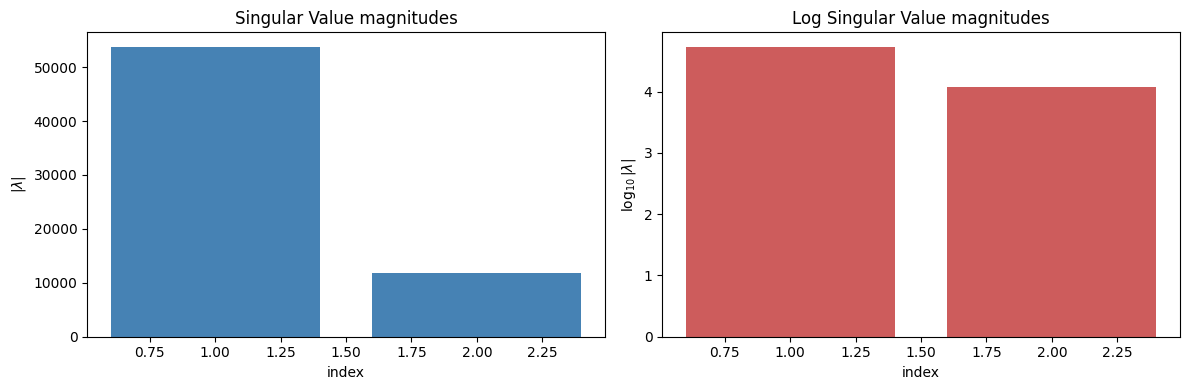

 33%|███▎      | 502/1500 [07:10<27:27,  1.65s/it]

**************************** DEBUG INFO START **********************************
Episode 501 is complete with reward 0.0
Replay_buffer_length 52425
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 34%|███▎      | 503/1500 [07:12<28:25,  1.71s/it]

**************************** DEBUG INFO START **********************************
Episode 502 is complete with reward 24.0
Replay_buffer_length 52449
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 34%|███▎      | 504/1500 [07:15<33:43,  2.03s/it]

...

**************************** DEBUG INFO START **********************************
Episode 547 is complete with reward 93.0
Replay_buffer_length 54003
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 37%|███▋      | 549/1500 [08:22<25:21,  1.60s/it]

**************************** DEBUG INFO START **********************************
Episode 548 is complete with reward 30.0
Replay_buffer_length 54033
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 37%|███▋      | 550/1500 [08:23<24:31,  1.55s/it]

**************************** DEBUG INFO START **********************************
Episode 549 is complete with reward 28.0
Replay_buffer_length 54061
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 550 avg_rewarg: 47.4
**************************** DEBUG INFO START **********************************
Episode 550 is complete with reward 28.0
Replay_buffer_length 54089
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


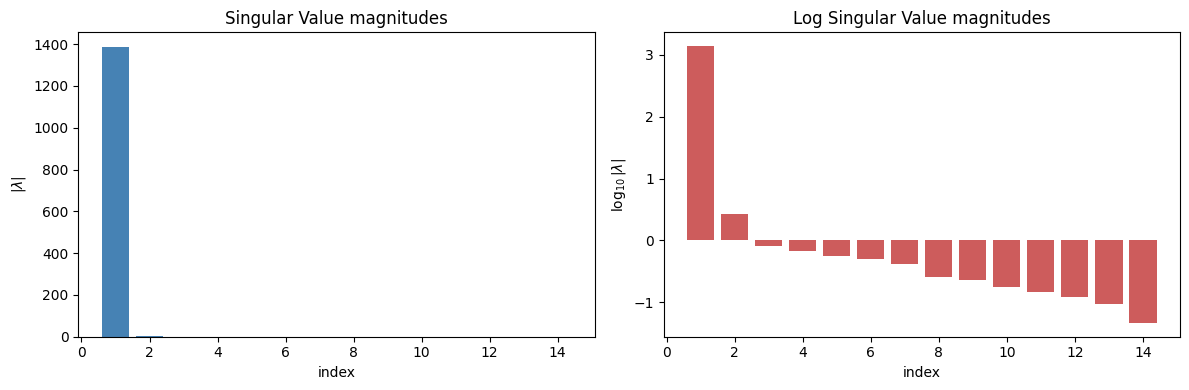

Q-function


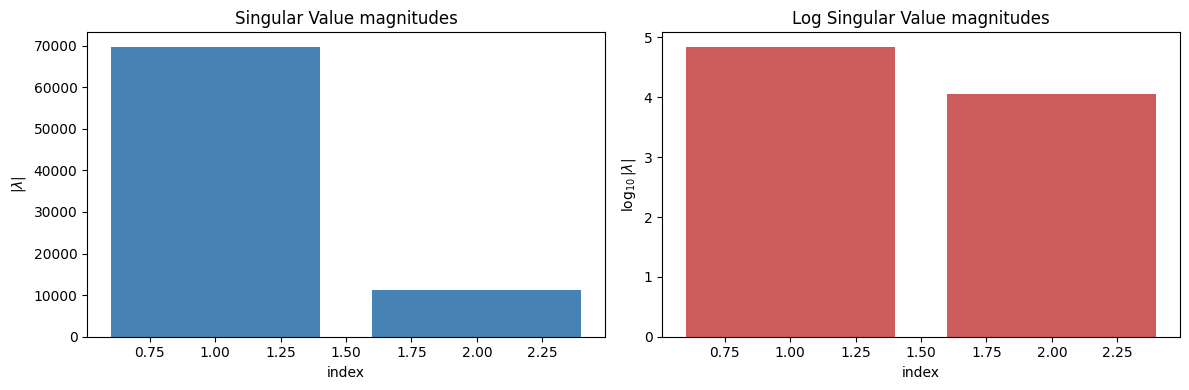

 37%|███▋      | 552/1500 [08:28<30:15,  1.92s/it]

**************************** DEBUG INFO START **********************************
Episode 551 is complete with reward 0.0
Replay_buffer_length 54090
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 37%|███▋      | 553/1500 [08:29<28:50,  1.83s/it]

**************************** DEBUG INFO START **********************************
Episode 552 is complete with reward 95.0
Replay_buffer_length 54185
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 37%|███▋      | 554/1500 [08:31<27:05,  1.72s/it]

...

**************************** DEBUG INFO START **********************************
Episode 597 is complete with reward 101.0
Replay_buffer_length 57925
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 40%|███▉      | 599/1500 [09:44<22:59,  1.53s/it]

**************************** DEBUG INFO START **********************************
Episode 598 is complete with reward 102.0
Replay_buffer_length 58027
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 40%|████      | 600/1500 [09:45<23:19,  1.55s/it]

**************************** DEBUG INFO START **********************************
Episode 599 is complete with reward 104.0
Replay_buffer_length 58131
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 600 avg_rewarg: 96.9
**************************** DEBUG INFO START **********************************
Episode 600 is complete with reward 95.0
Replay_buffer_length 58226
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


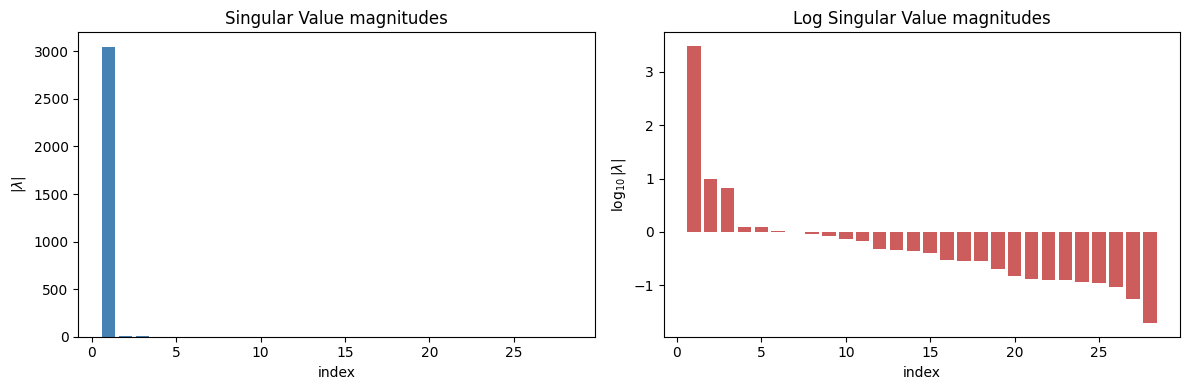

Q-function


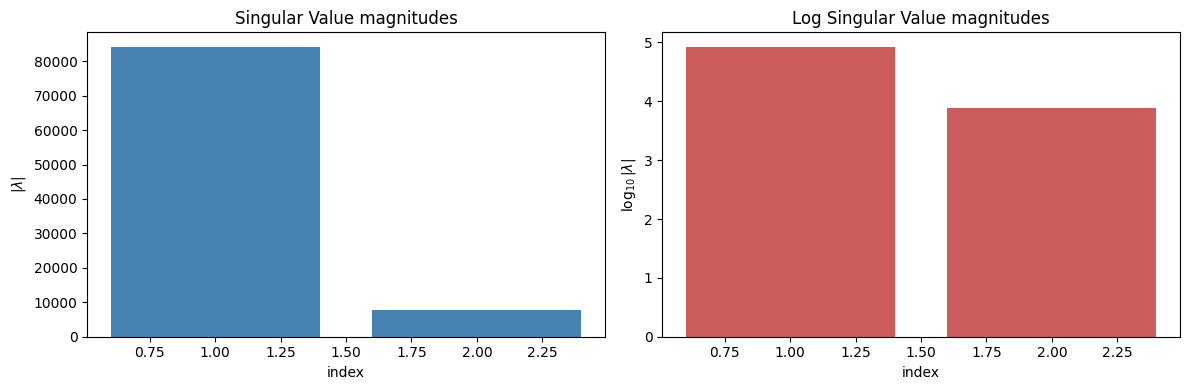

 40%|████      | 602/1500 [09:49<24:28,  1.63s/it]

**************************** DEBUG INFO START **********************************
Episode 601 is complete with reward 0.0
Replay_buffer_length 58227
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 40%|████      | 603/1500 [09:51<28:01,  1.87s/it]

**************************** DEBUG INFO START **********************************
Episode 602 is complete with reward 83.0
Replay_buffer_length 58310
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 40%|████      | 604/1500 [09:53<27:48,  1.86s/it]

...

**************************** DEBUG INFO START **********************************
Episode 647 is complete with reward 96.0
Replay_buffer_length 62602
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 43%|████▎     | 649/1500 [11:08<25:03,  1.77s/it]

**************************** DEBUG INFO START **********************************
Episode 648 is complete with reward 100.0
Replay_buffer_length 62702
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 43%|████▎     | 650/1500 [11:10<24:49,  1.75s/it]

**************************** DEBUG INFO START **********************************
Episode 649 is complete with reward 59.0
Replay_buffer_length 62761
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 650 avg_rewarg: 92.9
**************************** DEBUG INFO START **********************************
Episode 650 is complete with reward 100.0
Replay_buffer_length 62861
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


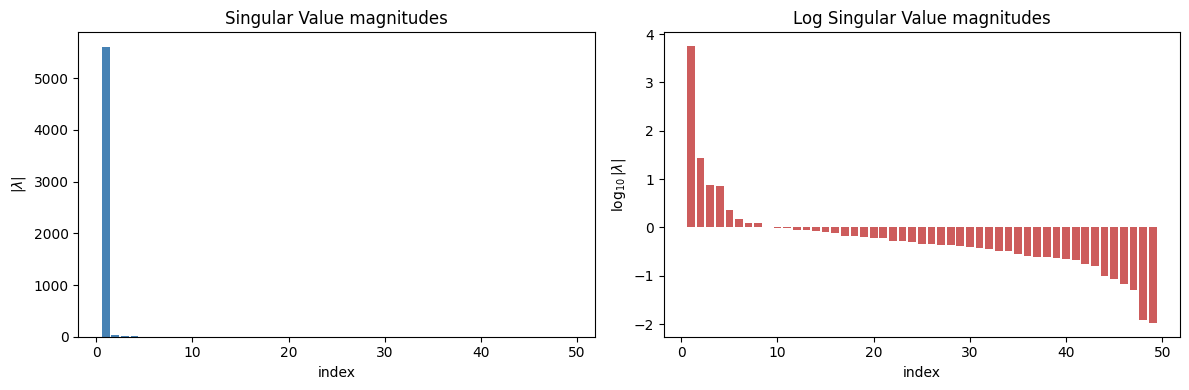

Q-function


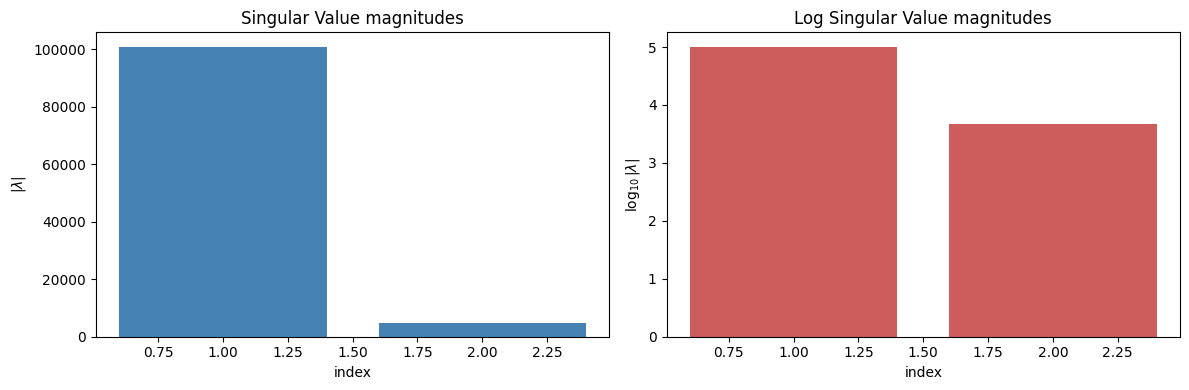

 43%|████▎     | 652/1500 [11:15<27:01,  1.91s/it]

**************************** DEBUG INFO START **********************************
Episode 651 is complete with reward 0.0
Replay_buffer_length 62862
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 44%|████▎     | 653/1500 [11:17<27:08,  1.92s/it]

**************************** DEBUG INFO START **********************************
Episode 652 is complete with reward 73.0
Replay_buffer_length 62935
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 44%|████▎     | 654/1500 [11:18<26:27,  1.88s/it]

...

**************************** DEBUG INFO START **********************************
Episode 697 is complete with reward 66.0
Replay_buffer_length 67069
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 47%|████▋     | 699/1500 [12:42<25:15,  1.89s/it]

**************************** DEBUG INFO START **********************************
Episode 698 is complete with reward 108.0
Replay_buffer_length 67177
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 47%|████▋     | 700/1500 [12:44<25:42,  1.93s/it]

**************************** DEBUG INFO START **********************************
Episode 699 is complete with reward 106.0
Replay_buffer_length 67283
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 700 avg_rewarg: 94.6
**************************** DEBUG INFO START **********************************
Episode 700 is complete with reward 91.0
Replay_buffer_length 67374
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


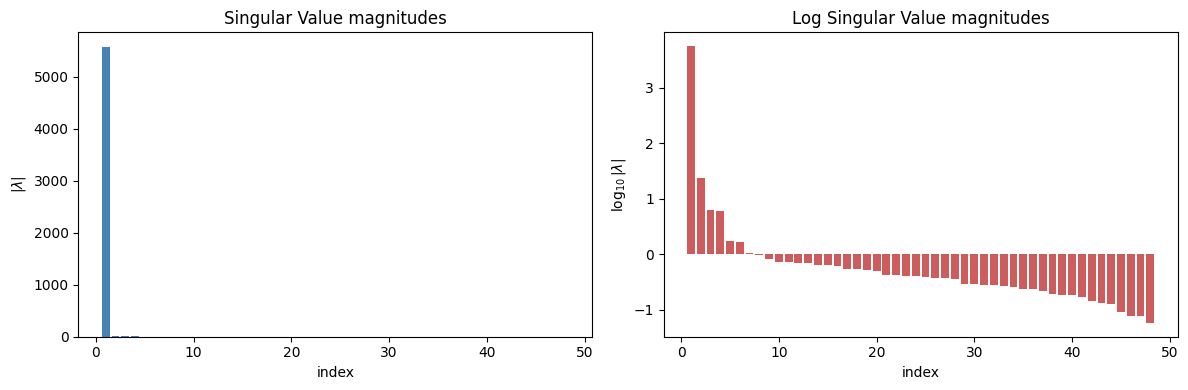

Q-function


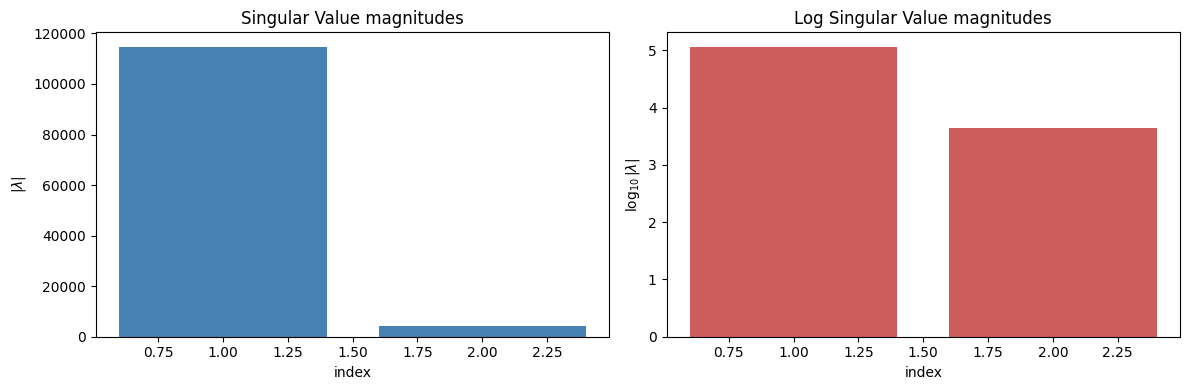

 47%|████▋     | 702/1500 [12:48<26:12,  1.97s/it]

**************************** DEBUG INFO START **********************************
Episode 701 is complete with reward 0.0
Replay_buffer_length 67375
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 47%|████▋     | 703/1500 [12:50<25:11,  1.90s/it]

**************************** DEBUG INFO START **********************************
Episode 702 is complete with reward 81.0
Replay_buffer_length 67456
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 47%|████▋     | 704/1500 [12:52<24:57,  1.88s/it]

...

**************************** DEBUG INFO START **********************************
Episode 747 is complete with reward 44.0
Replay_buffer_length 71264
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 50%|████▉     | 749/1500 [14:29<38:17,  3.06s/it]

**************************** DEBUG INFO START **********************************
Episode 748 is complete with reward 61.0
Replay_buffer_length 71325
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 50%|█████     | 750/1500 [14:32<36:11,  2.89s/it]

**************************** DEBUG INFO START **********************************
Episode 749 is complete with reward 141.0
Replay_buffer_length 71466
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 750 avg_rewarg: 70.8
**************************** DEBUG INFO START **********************************
Episode 750 is complete with reward 128.0
Replay_buffer_length 71594
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


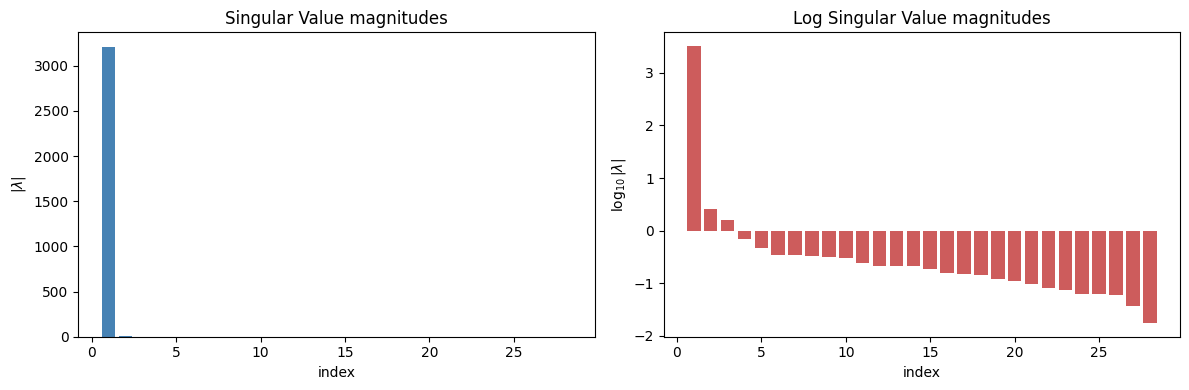

Q-function


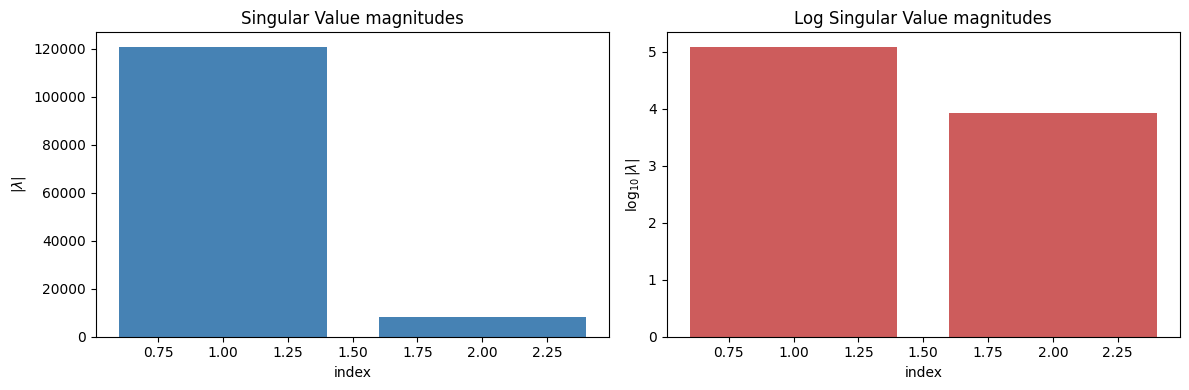

 50%|█████     | 752/1500 [14:36<30:55,  2.48s/it]

**************************** DEBUG INFO START **********************************
Episode 751 is complete with reward 0.0
Replay_buffer_length 71595
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 50%|█████     | 753/1500 [14:38<28:08,  2.26s/it]

**************************** DEBUG INFO START **********************************
Episode 752 is complete with reward 58.0
Replay_buffer_length 71653
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 50%|█████     | 754/1500 [14:40<27:40,  2.23s/it]

...

**************************** DEBUG INFO START **********************************
Episode 797 is complete with reward 50.0
Replay_buffer_length 77000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 53%|█████▎    | 799/1500 [16:25<25:55,  2.22s/it]

**************************** DEBUG INFO START **********************************
Episode 798 is complete with reward 103.0
Replay_buffer_length 77103
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 53%|█████▎    | 800/1500 [16:27<25:25,  2.18s/it]

**************************** DEBUG INFO START **********************************
Episode 799 is complete with reward 59.0
Replay_buffer_length 77162
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 800 avg_rewarg: 63.3
**************************** DEBUG INFO START **********************************
Episode 800 is complete with reward 35.0
Replay_buffer_length 77197
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


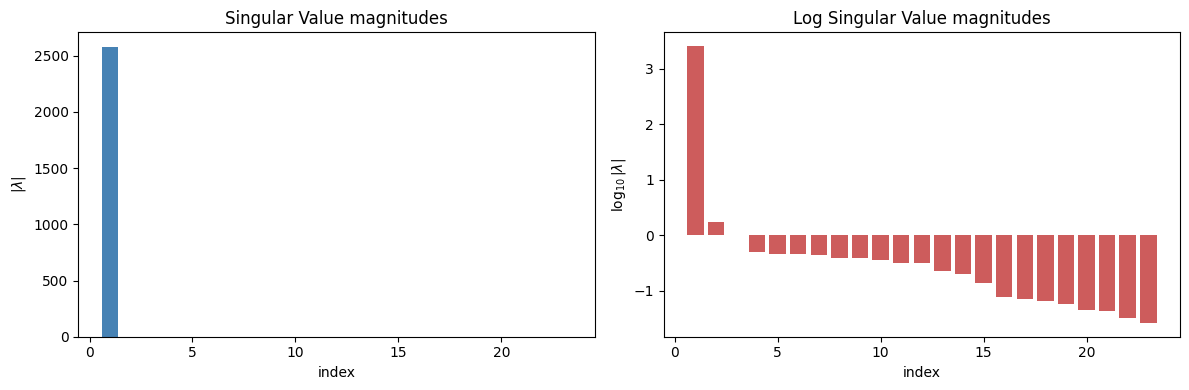

Q-function


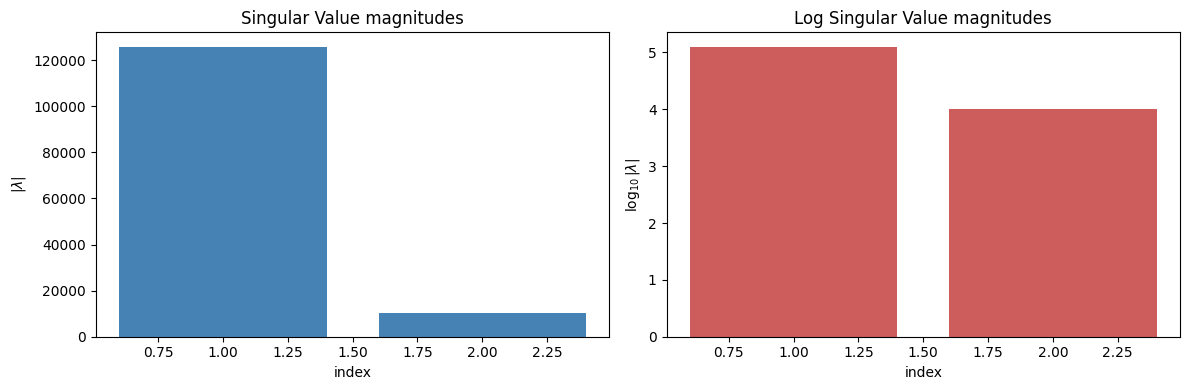

 53%|█████▎    | 802/1500 [16:32<26:23,  2.27s/it]

**************************** DEBUG INFO START **********************************
Episode 801 is complete with reward 0.0
Replay_buffer_length 77198
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 54%|█████▎    | 803/1500 [16:34<26:39,  2.29s/it]

**************************** DEBUG INFO START **********************************
Episode 802 is complete with reward 118.0
Replay_buffer_length 77316
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 54%|█████▎    | 804/1500 [16:36<24:56,  2.15s/it]

...

**************************** DEBUG INFO START **********************************
Episode 847 is complete with reward 123.0
Replay_buffer_length 80836
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 57%|█████▋    | 849/1500 [18:25<27:59,  2.58s/it]

**************************** DEBUG INFO START **********************************
Episode 848 is complete with reward 114.0
Replay_buffer_length 80950
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 57%|█████▋    | 850/1500 [18:28<27:50,  2.57s/it]

**************************** DEBUG INFO START **********************************
Episode 849 is complete with reward 90.0
Replay_buffer_length 81040
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 850 avg_rewarg: 90.9
**************************** DEBUG INFO START **********************************
Episode 850 is complete with reward 90.0
Replay_buffer_length 81130
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


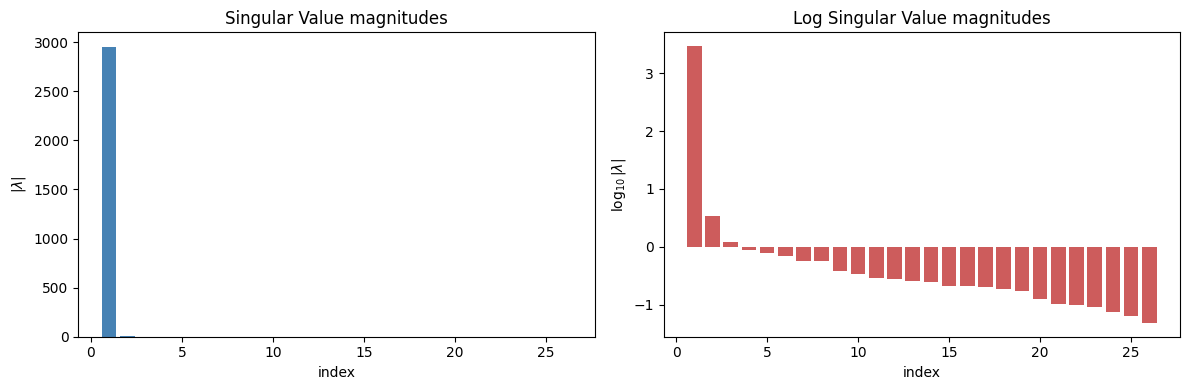

Q-function


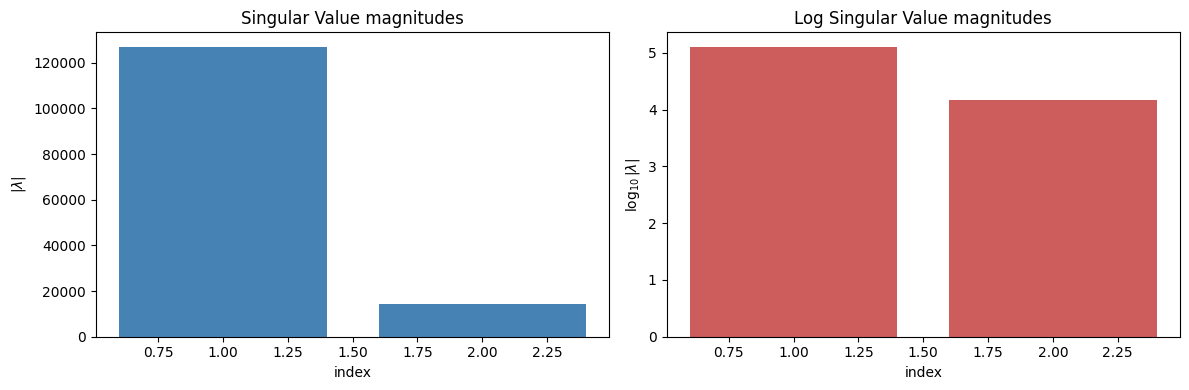

 57%|█████▋    | 852/1500 [18:33<27:51,  2.58s/it]

**************************** DEBUG INFO START **********************************
Episode 851 is complete with reward 0.0
Replay_buffer_length 81131
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 57%|█████▋    | 853/1500 [18:35<26:17,  2.44s/it]

**************************** DEBUG INFO START **********************************
Episode 852 is complete with reward 98.0
Replay_buffer_length 81229
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 57%|█████▋    | 854/1500 [18:37<26:07,  2.43s/it]

...

**************************** DEBUG INFO START **********************************
Episode 897 is complete with reward 112.0
Replay_buffer_length 85643
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 60%|█████▉    | 899/1500 [20:36<24:25,  2.44s/it]

**************************** DEBUG INFO START **********************************
Episode 898 is complete with reward 110.0
Replay_buffer_length 85753
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 60%|██████    | 900/1500 [20:39<25:46,  2.58s/it]

**************************** DEBUG INFO START **********************************
Episode 899 is complete with reward 108.0
Replay_buffer_length 85861
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 900 avg_rewarg: 109.7
**************************** DEBUG INFO START **********************************
Episode 900 is complete with reward 112.0
Replay_buffer_length 85973
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


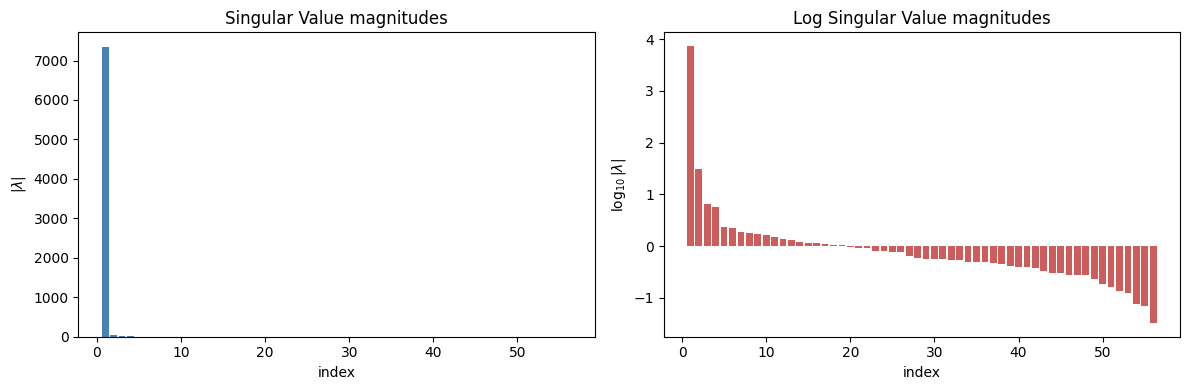

Q-function


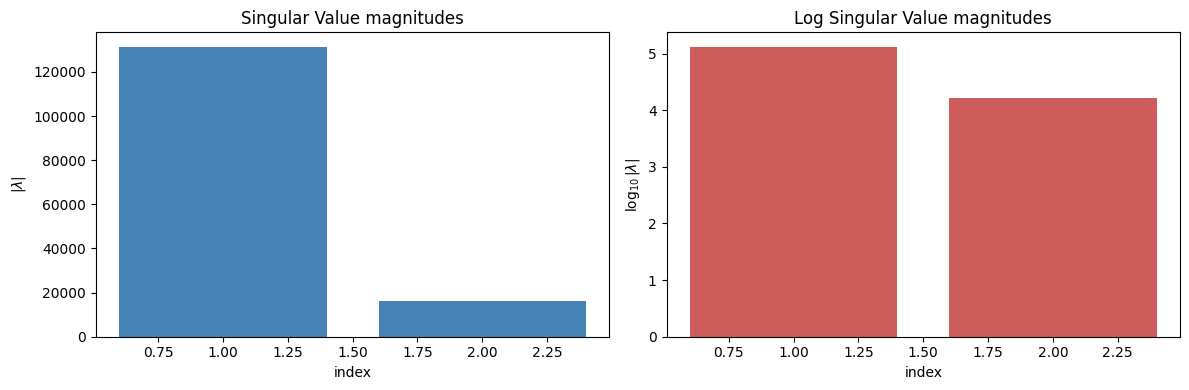

 60%|██████    | 902/1500 [20:45<26:52,  2.70s/it]

**************************** DEBUG INFO START **********************************
Episode 901 is complete with reward 0.0
Replay_buffer_length 85974
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 60%|██████    | 903/1500 [20:47<26:14,  2.64s/it]

**************************** DEBUG INFO START **********************************
Episode 902 is complete with reward 106.0
Replay_buffer_length 86080
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 60%|██████    | 904/1500 [20:50<27:07,  2.73s/it]

...

**************************** DEBUG INFO START **********************************
Episode 947 is complete with reward 36.0
Replay_buffer_length 89523
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 63%|██████▎   | 949/1500 [22:53<24:33,  2.67s/it]

**************************** DEBUG INFO START **********************************
Episode 948 is complete with reward 38.0
Replay_buffer_length 89561
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 63%|██████▎   | 950/1500 [22:56<25:53,  2.83s/it]

**************************** DEBUG INFO START **********************************
Episode 949 is complete with reward 32.0
Replay_buffer_length 89593
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 950 avg_rewarg: 47.6
**************************** DEBUG INFO START **********************************
Episode 950 is complete with reward 48.0
Replay_buffer_length 89641
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


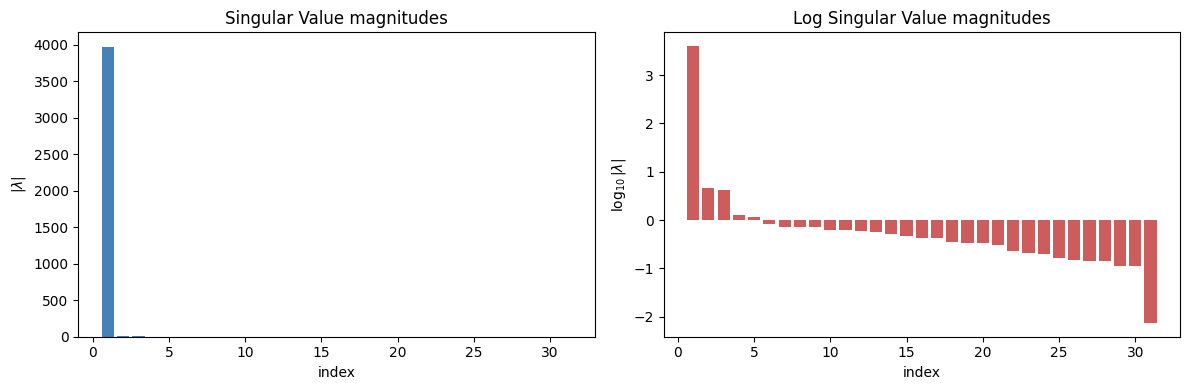

Q-function


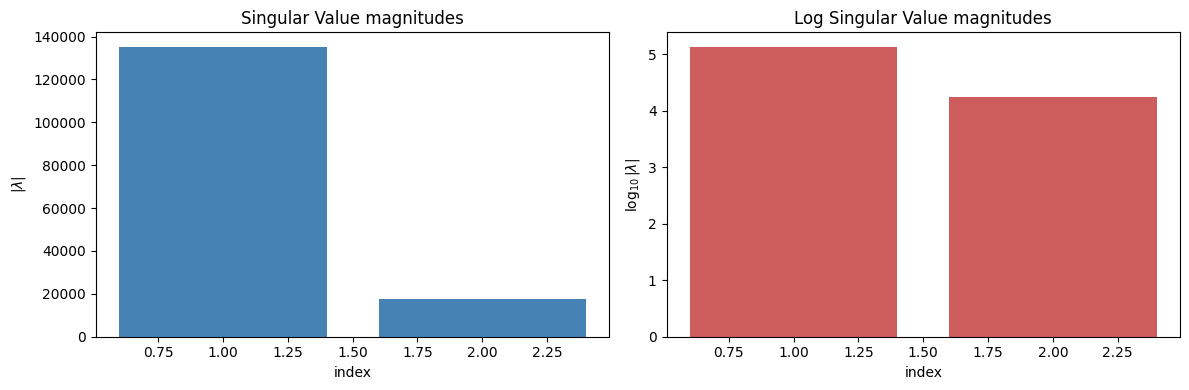

 63%|██████▎   | 952/1500 [23:02<26:18,  2.88s/it]

**************************** DEBUG INFO START **********************************
Episode 951 is complete with reward 32.0
Replay_buffer_length 89674
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 64%|██████▎   | 953/1500 [23:05<25:12,  2.77s/it]

**************************** DEBUG INFO START **********************************
Episode 952 is complete with reward 98.0
Replay_buffer_length 89772
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 64%|██████▎   | 954/1500 [23:08<25:31,  2.80s/it]

...

**************************** DEBUG INFO START **********************************
Episode 997 is complete with reward 97.0
Replay_buffer_length 93372
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 67%|██████▋   | 999/1500 [25:29<26:57,  3.23s/it]

**************************** DEBUG INFO START **********************************
Episode 998 is complete with reward 103.0
Replay_buffer_length 93475
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 67%|██████▋   | 1000/1500 [25:31<25:02,  3.01s/it]

**************************** DEBUG INFO START **********************************
Episode 999 is complete with reward 96.0
Replay_buffer_length 93571
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1000 avg_rewarg: 99.3
**************************** DEBUG INFO START **********************************
Episode 1000 is complete with reward 111.0
Replay_buffer_length 93682
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


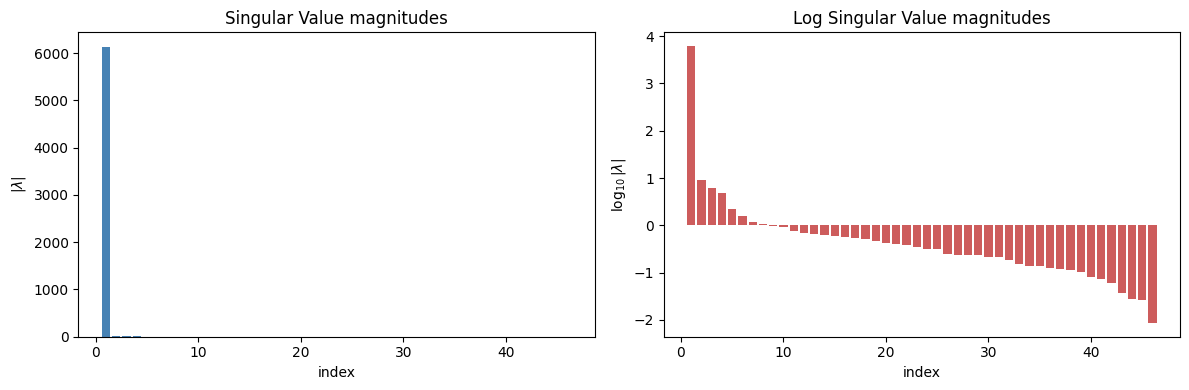

Q-function


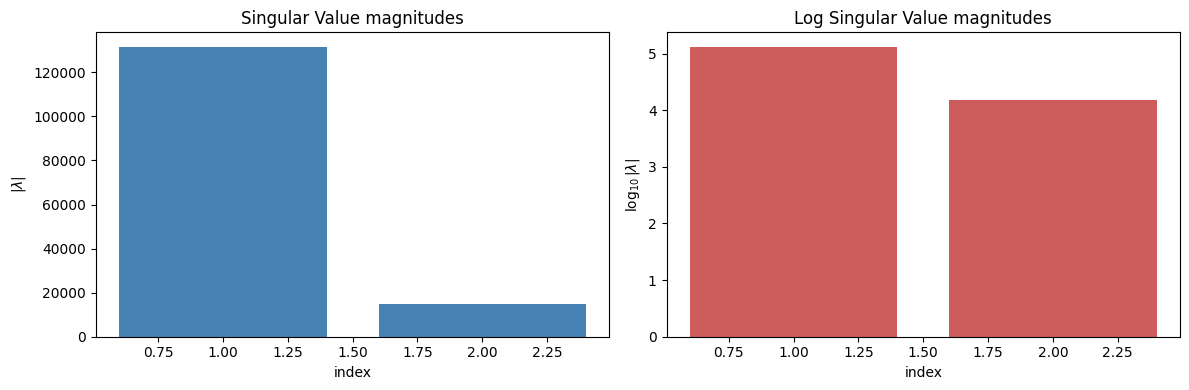

 67%|██████▋   | 1002/1500 [25:38<26:23,  3.18s/it]

**************************** DEBUG INFO START **********************************
Episode 1001 is complete with reward 0.0
Replay_buffer_length 93683
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 67%|██████▋   | 1003/1500 [25:41<26:16,  3.17s/it]

**************************** DEBUG INFO START **********************************
Episode 1002 is complete with reward 109.0
Replay_buffer_length 93792
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 67%|██████▋   | 1004/1500 [25:44<25:42,  3.11s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1047 is complete with reward 21.0
Replay_buffer_length 96970
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 70%|██████▉   | 1049/1500 [28:12<25:06,  3.34s/it]

**************************** DEBUG INFO START **********************************
Episode 1048 is complete with reward 21.0
Replay_buffer_length 96991
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 70%|███████   | 1050/1500 [28:15<24:52,  3.32s/it]

**************************** DEBUG INFO START **********************************
Episode 1049 is complete with reward 111.0
Replay_buffer_length 97102
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1050 avg_rewarg: 47.0
**************************** DEBUG INFO START **********************************
Episode 1050 is complete with reward 21.0
Replay_buffer_length 97123
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


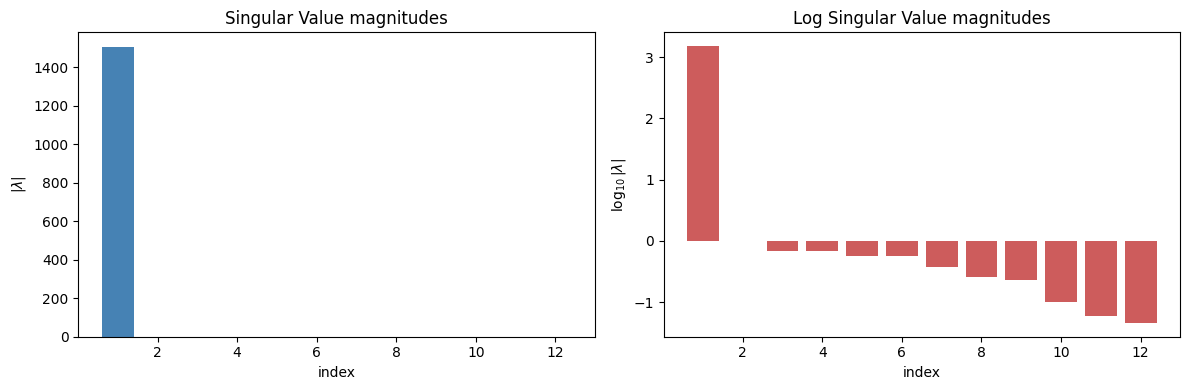

Q-function


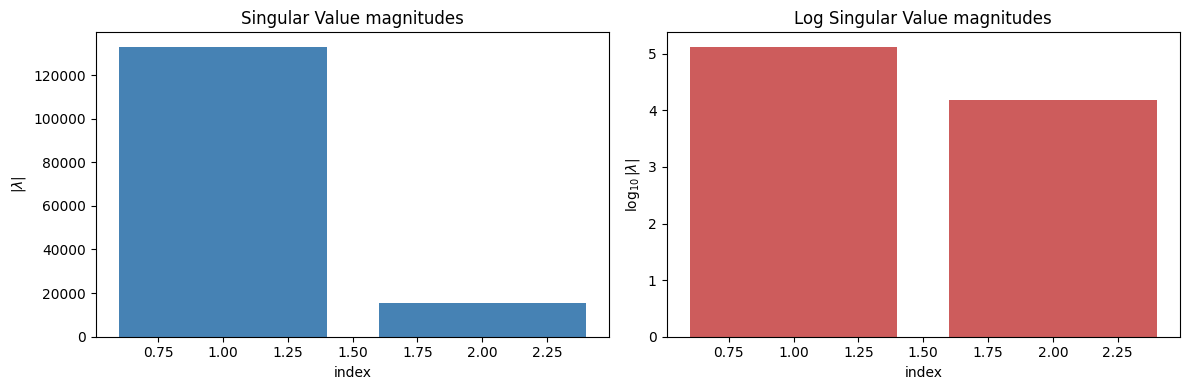

 70%|███████   | 1052/1500 [28:22<24:14,  3.25s/it]

**************************** DEBUG INFO START **********************************
Episode 1051 is complete with reward 0.0
Replay_buffer_length 97124
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 70%|███████   | 1053/1500 [28:25<24:47,  3.33s/it]

**************************** DEBUG INFO START **********************************
Episode 1052 is complete with reward 25.0
Replay_buffer_length 97149
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 70%|███████   | 1054/1500 [28:28<23:53,  3.21s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1097 is complete with reward 21.0
Replay_buffer_length 99077
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 73%|███████▎  | 1099/1500 [31:01<22:52,  3.42s/it]

**************************** DEBUG INFO START **********************************
Episode 1098 is complete with reward 11.0
Replay_buffer_length 99088
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 73%|███████▎  | 1100/1500 [31:04<22:20,  3.35s/it]

**************************** DEBUG INFO START **********************************
Episode 1099 is complete with reward 24.0
Replay_buffer_length 99112
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1100 avg_rewarg: 35.4
**************************** DEBUG INFO START **********************************
Episode 1100 is complete with reward 21.0
Replay_buffer_length 99133
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


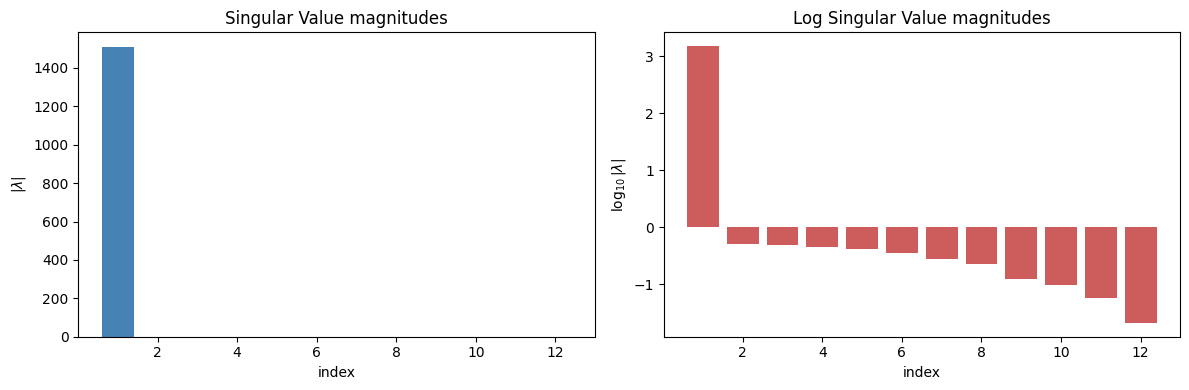

Q-function


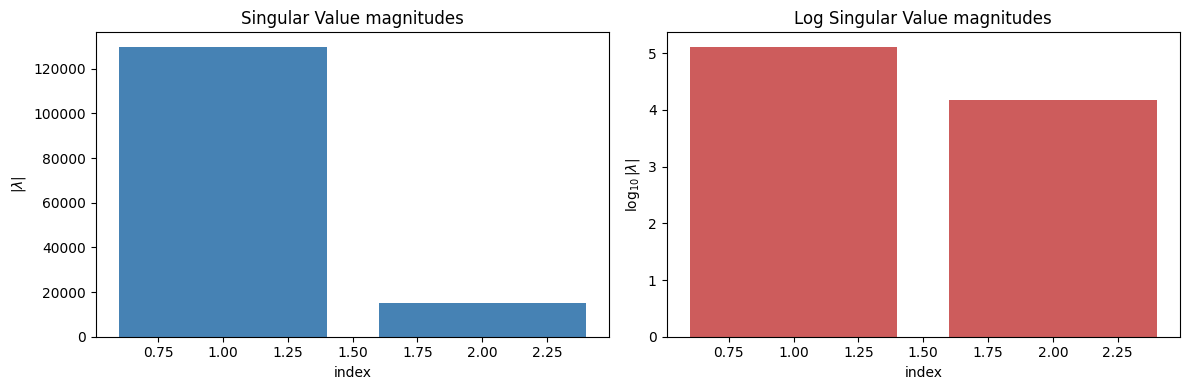

 73%|███████▎  | 1102/1500 [31:10<21:55,  3.31s/it]

**************************** DEBUG INFO START **********************************
Episode 1101 is complete with reward 0.0
Replay_buffer_length 99134
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 74%|███████▎  | 1103/1500 [31:14<21:44,  3.29s/it]

**************************** DEBUG INFO START **********************************
Episode 1102 is complete with reward 36.0
Replay_buffer_length 99170
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 74%|███████▎  | 1104/1500 [31:16<20:52,  3.16s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1147 is complete with reward 90.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 77%|███████▋  | 1149/1500 [33:52<23:33,  4.03s/it]

**************************** DEBUG INFO START **********************************
Episode 1148 is complete with reward 90.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 77%|███████▋  | 1150/1500 [33:56<22:42,  3.89s/it]

**************************** DEBUG INFO START **********************************
Episode 1149 is complete with reward 88.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1150 avg_rewarg: 91.0
**************************** DEBUG INFO START **********************************
Episode 1150 is complete with reward 88.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


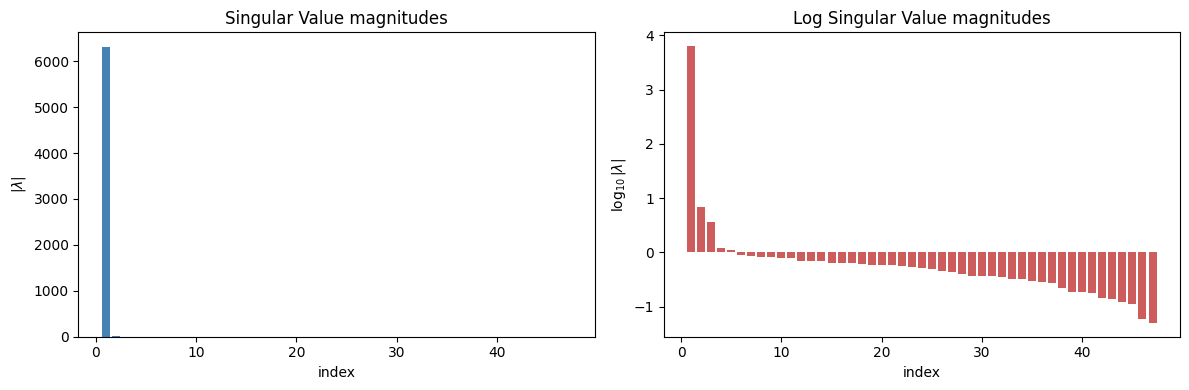

Q-function


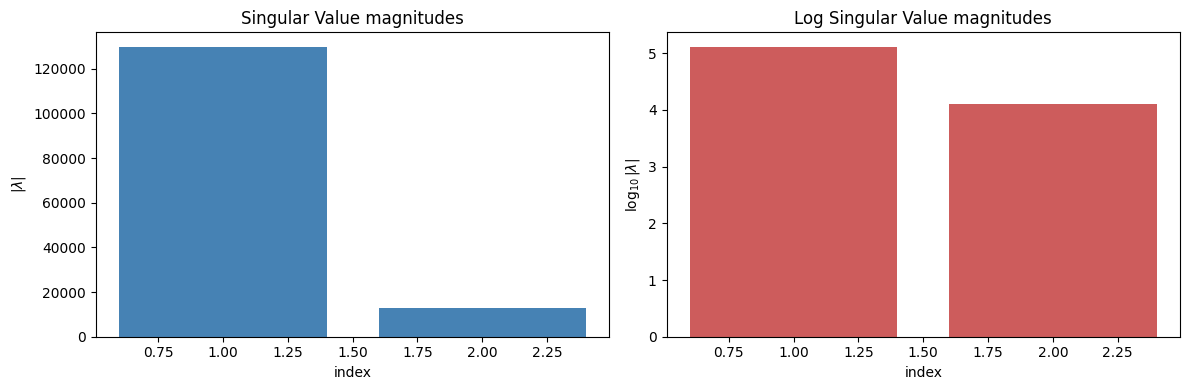

 77%|███████▋  | 1152/1500 [34:04<22:40,  3.91s/it]

**************************** DEBUG INFO START **********************************
Episode 1151 is complete with reward 0.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 77%|███████▋  | 1153/1500 [34:08<21:59,  3.80s/it]

**************************** DEBUG INFO START **********************************
Episode 1152 is complete with reward 93.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 77%|███████▋  | 1154/1500 [34:11<21:17,  3.69s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1197 is complete with reward 93.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 80%|███████▉  | 1199/1500 [37:04<19:25,  3.87s/it]

**************************** DEBUG INFO START **********************************
Episode 1198 is complete with reward 95.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 80%|████████  | 1200/1500 [37:07<18:34,  3.72s/it]

**************************** DEBUG INFO START **********************************
Episode 1199 is complete with reward 92.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1200 avg_rewarg: 94.6
**************************** DEBUG INFO START **********************************
Episode 1200 is complete with reward 93.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


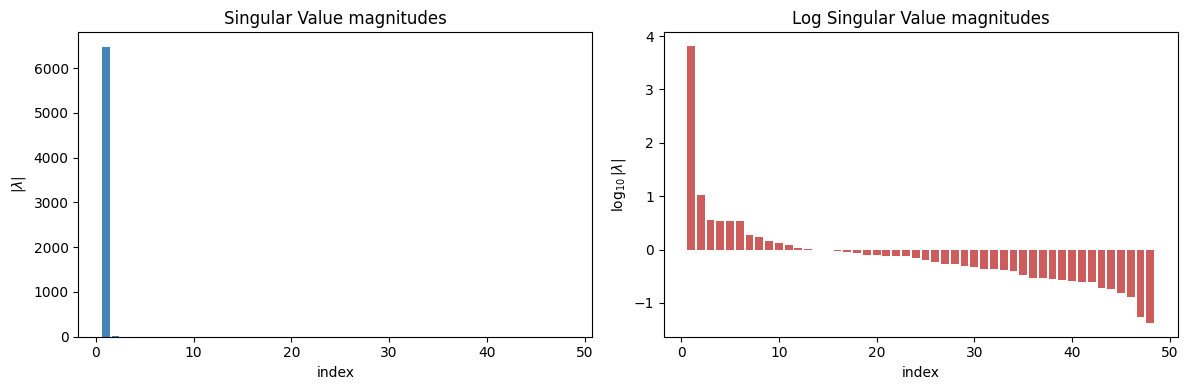

Q-function


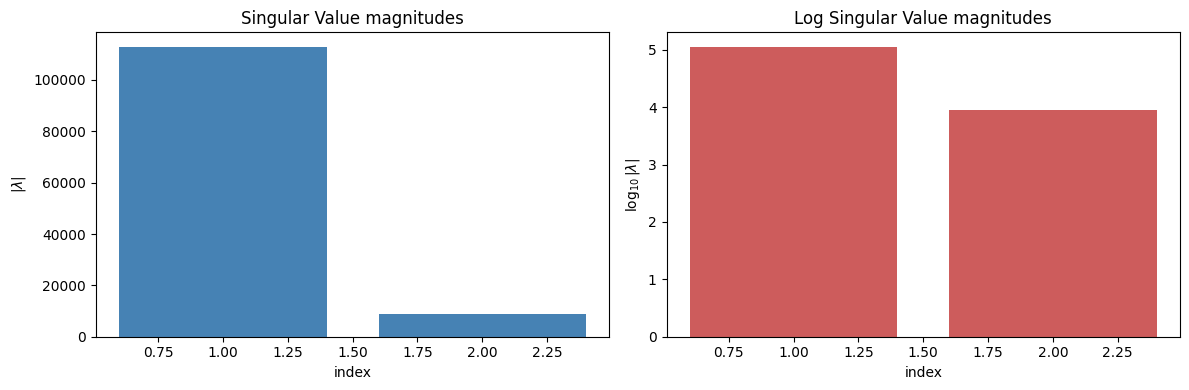

 80%|████████  | 1202/1500 [37:19<23:58,  4.83s/it]

**************************** DEBUG INFO START **********************************
Episode 1201 is complete with reward 0.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 80%|████████  | 1203/1500 [37:22<21:10,  4.28s/it]

**************************** DEBUG INFO START **********************************
Episode 1202 is complete with reward 94.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 80%|████████  | 1204/1500 [37:25<19:17,  3.91s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1247 is complete with reward 102.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 83%|████████▎ | 1249/1500 [40:15<14:43,  3.52s/it]

**************************** DEBUG INFO START **********************************
Episode 1248 is complete with reward 96.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 83%|████████▎ | 1250/1500 [40:18<14:21,  3.45s/it]

**************************** DEBUG INFO START **********************************
Episode 1249 is complete with reward 164.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1250 avg_rewarg: 111.7
**************************** DEBUG INFO START **********************************
Episode 1250 is complete with reward 96.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


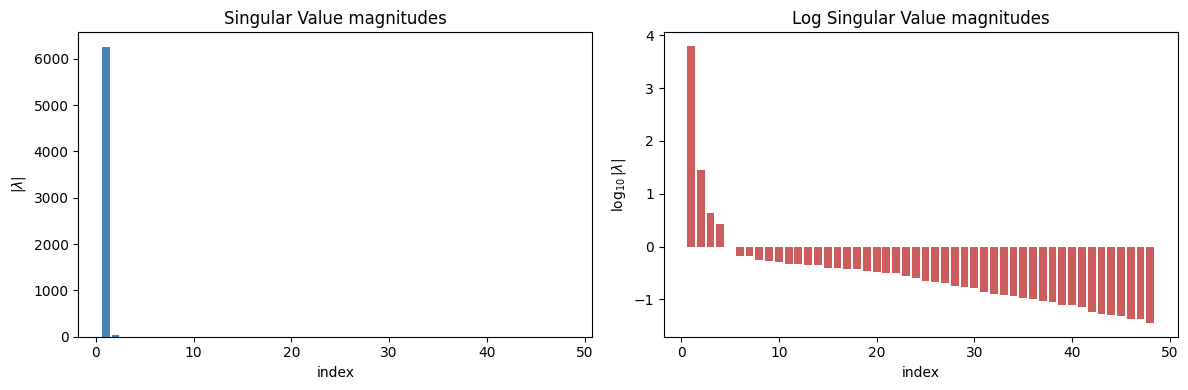

Q-function


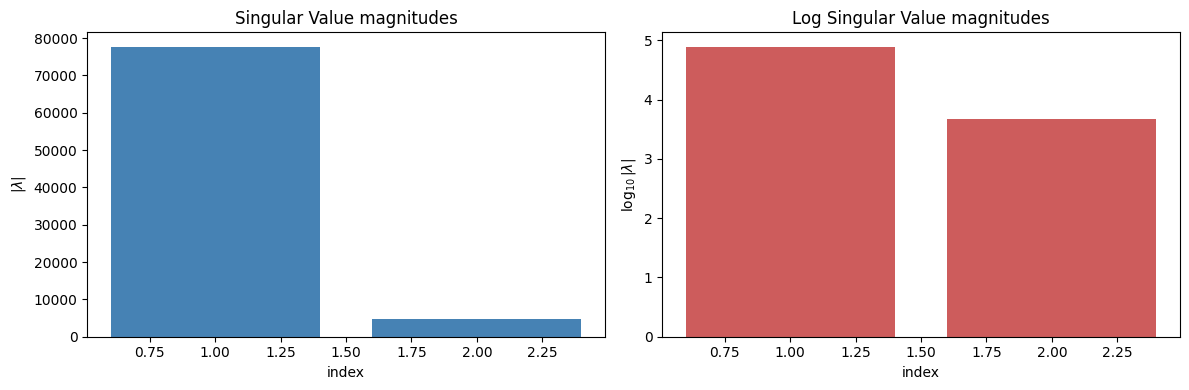

 83%|████████▎ | 1252/1500 [40:26<15:47,  3.82s/it]

**************************** DEBUG INFO START **********************************
Episode 1251 is complete with reward 0.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 84%|████████▎ | 1253/1500 [40:30<15:32,  3.78s/it]

**************************** DEBUG INFO START **********************************
Episode 1252 is complete with reward 97.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 84%|████████▎ | 1254/1500 [40:34<16:02,  3.91s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1297 is complete with reward 97.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 87%|████████▋ | 1299/1500 [43:18<11:33,  3.45s/it]

**************************** DEBUG INFO START **********************************
Episode 1298 is complete with reward 101.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 87%|████████▋ | 1300/1500 [43:22<12:10,  3.65s/it]

**************************** DEBUG INFO START **********************************
Episode 1299 is complete with reward 105.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1300 avg_rewarg: 99.7
**************************** DEBUG INFO START **********************************
Episode 1300 is complete with reward 88.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


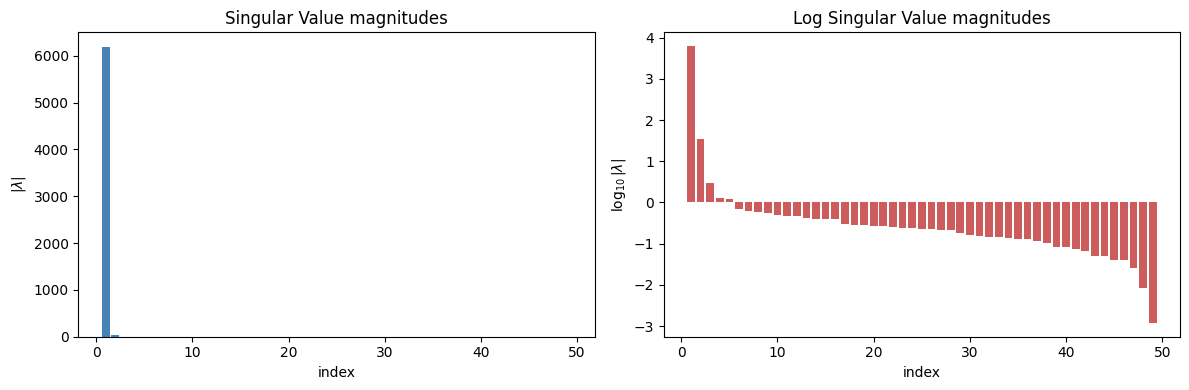

Q-function


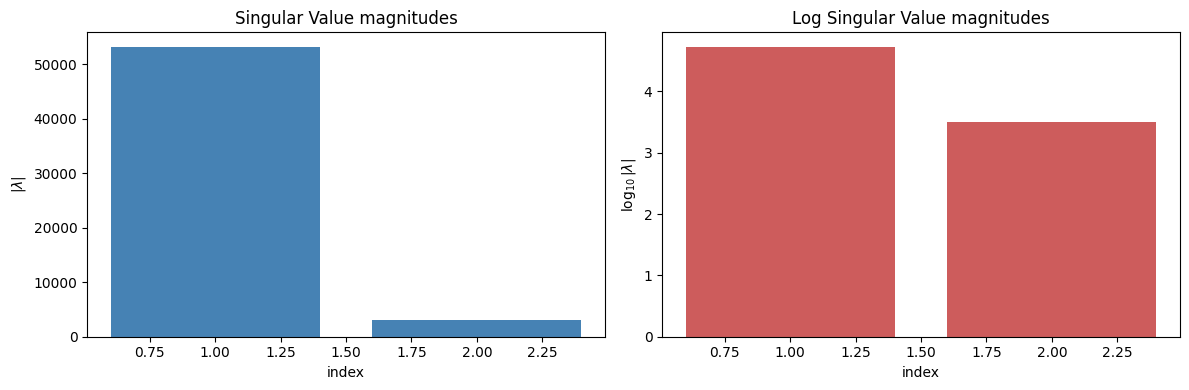

 87%|████████▋ | 1302/1500 [43:32<13:33,  4.11s/it]

**************************** DEBUG INFO START **********************************
Episode 1301 is complete with reward 0.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 87%|████████▋ | 1303/1500 [43:35<13:11,  4.02s/it]

**************************** DEBUG INFO START **********************************
Episode 1302 is complete with reward 106.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 87%|████████▋ | 1304/1500 [43:38<11:54,  3.65s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1347 is complete with reward 119.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 90%|████████▉ | 1349/1500 [47:01<09:49,  3.91s/it]

**************************** DEBUG INFO START **********************************
Episode 1348 is complete with reward 119.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 90%|█████████ | 1350/1500 [47:05<09:47,  3.92s/it]

**************************** DEBUG INFO START **********************************
Episode 1349 is complete with reward 132.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1350 avg_rewarg: 120.7
**************************** DEBUG INFO START **********************************
Episode 1350 is complete with reward 107.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


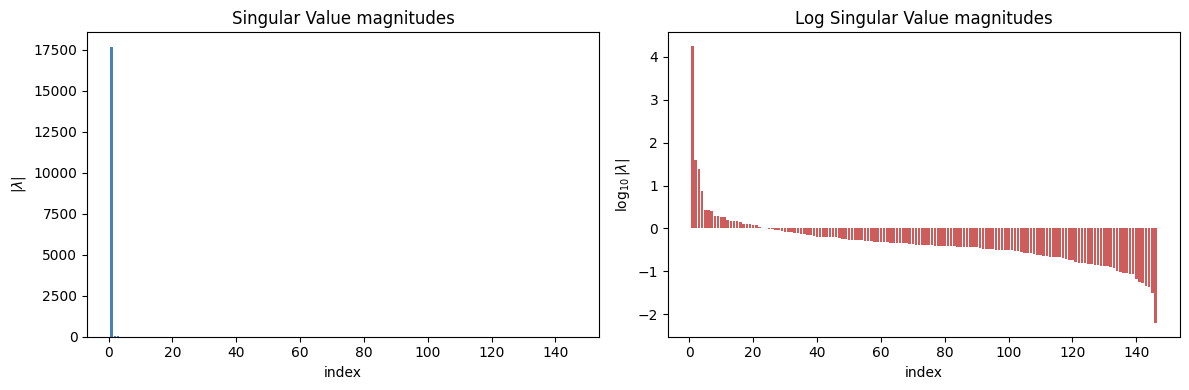

Q-function


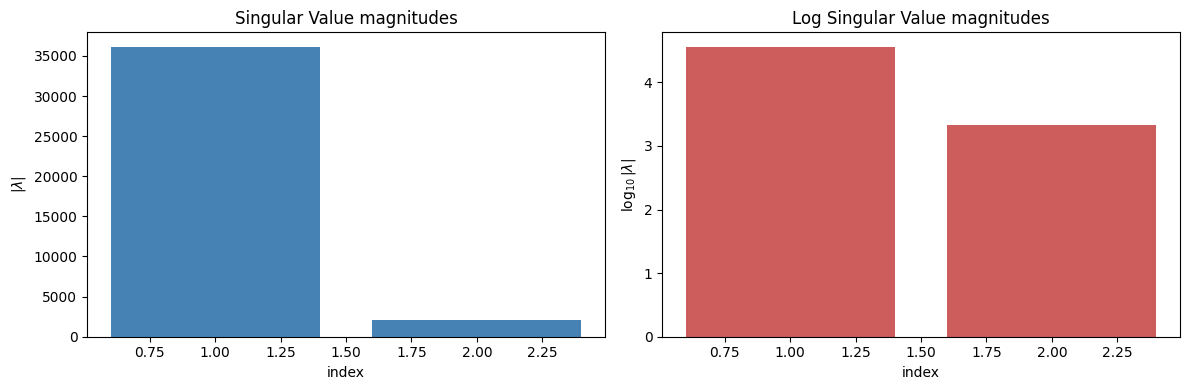

 90%|█████████ | 1352/1500 [47:15<11:06,  4.50s/it]

**************************** DEBUG INFO START **********************************
Episode 1351 is complete with reward 1.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 90%|█████████ | 1353/1500 [47:18<09:47,  4.00s/it]

**************************** DEBUG INFO START **********************************
Episode 1352 is complete with reward 99.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 90%|█████████ | 1354/1500 [47:22<09:39,  3.97s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1397 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 93%|█████████▎| 1399/1500 [50:39<07:46,  4.62s/it]

**************************** DEBUG INFO START **********************************
Episode 1398 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 93%|█████████▎| 1400/1500 [50:44<08:14,  4.94s/it]

**************************** DEBUG INFO START **********************************
Episode 1399 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1400 avg_rewarg: 420.4
**************************** DEBUG INFO START **********************************
Episode 1400 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


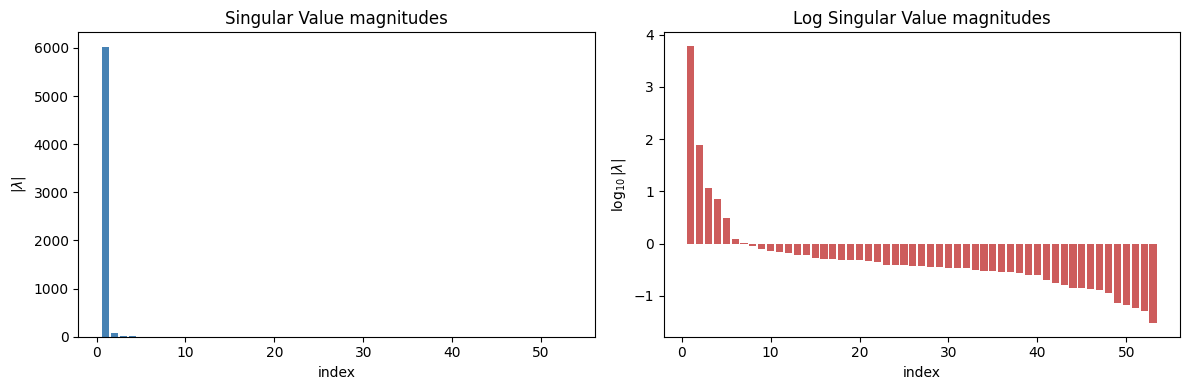

Q-function


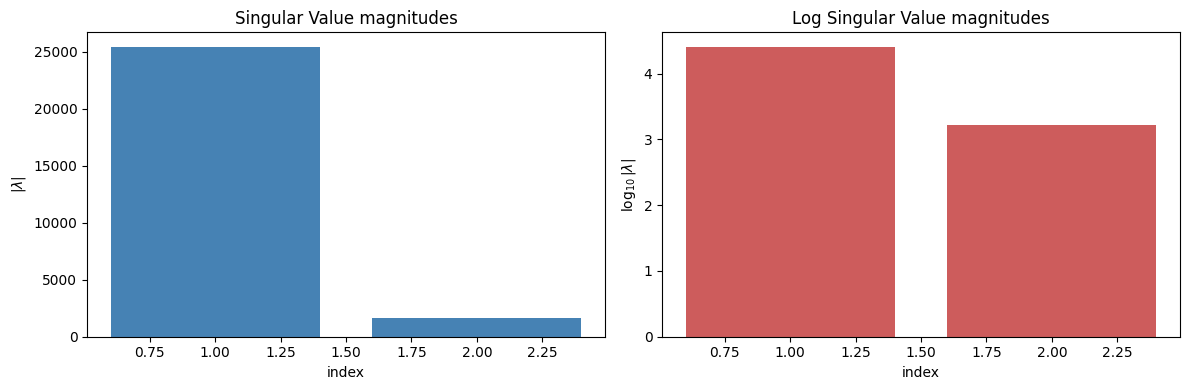

 93%|█████████▎| 1402/1500 [50:58<09:42,  5.94s/it]

**************************** DEBUG INFO START **********************************
Episode 1401 is complete with reward 0.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 94%|█████████▎| 1403/1500 [51:05<09:50,  6.08s/it]

**************************** DEBUG INFO START **********************************
Episode 1402 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 94%|█████████▎| 1404/1500 [51:08<08:23,  5.25s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1447 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 97%|█████████▋| 1449/1500 [55:21<03:56,  4.64s/it]

**************************** DEBUG INFO START **********************************
Episode 1448 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 97%|█████████▋| 1450/1500 [55:27<04:19,  5.19s/it]

**************************** DEBUG INFO START **********************************
Episode 1449 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
episode 1450 avg_rewarg: 500.0
**************************** DEBUG INFO START **********************************
Episode 1450 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************
Hankel Value Function


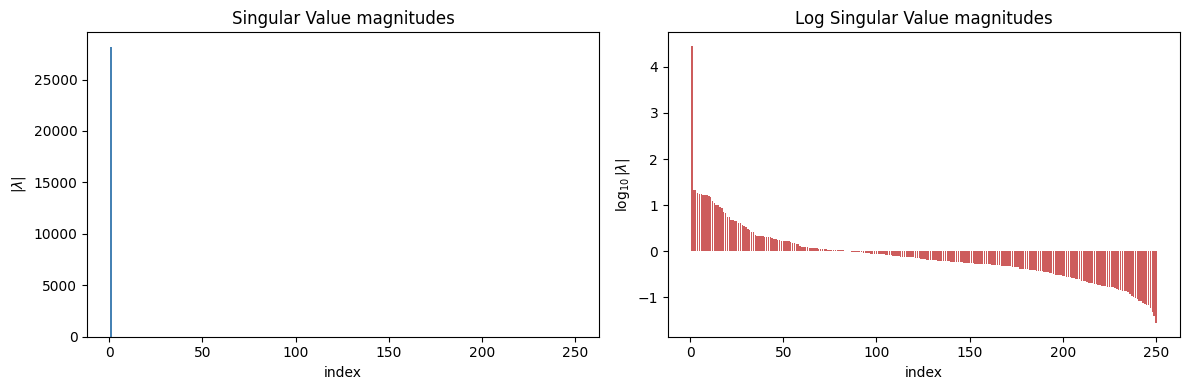

Q-function


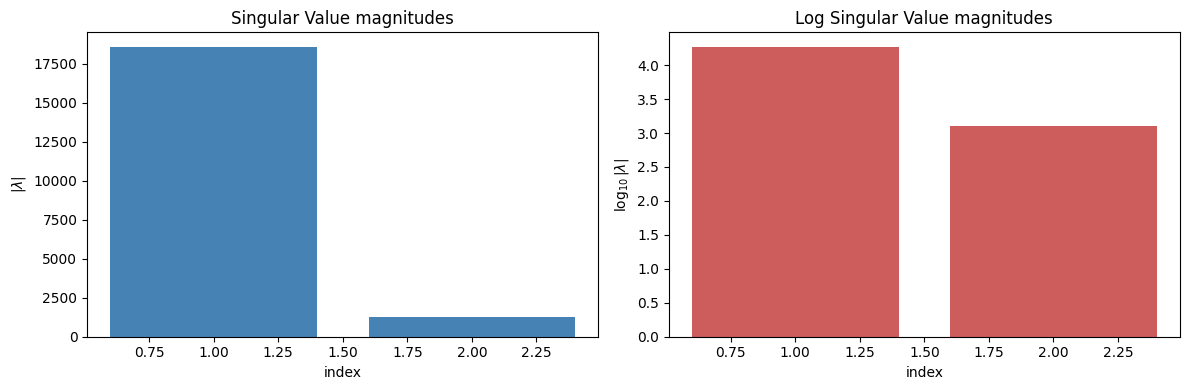

 97%|█████████▋| 1452/1500 [55:38<04:17,  5.36s/it]

**************************** DEBUG INFO START **********************************
Episode 1451 is complete with reward 1.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 97%|█████████▋| 1453/1500 [55:44<04:17,  5.47s/it]

**************************** DEBUG INFO START **********************************
Episode 1452 is complete with reward 500.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


 97%|█████████▋| 1454/1500 [55:48<03:44,  4.88s/it]

...

**************************** DEBUG INFO START **********************************
Episode 1497 is complete with reward 104.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


100%|█████████▉| 1499/1500 [58:50<00:04,  4.10s/it]

**************************** DEBUG INFO START **********************************
Episode 1498 is complete with reward 102.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


100%|██████████| 1500/1500 [58:56<00:00,  2.36s/it]

**************************** DEBUG INFO START **********************************
Episode 1499 is complete with reward 97.0
Replay_buffer_length 100000
Epsilon for epsilon-greedy is 0.01
**************************** DEBUG INFO END **********************************


In [14]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    np_seed=seed,
    analysis_config = analysis,
    DEBUG=True
)

## Training and Analysis Plots (now with pi*(theeta))

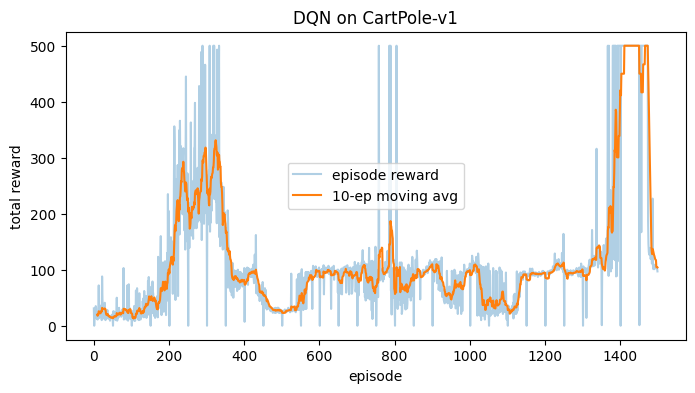

In [15]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on CartPole-v1")
plt.legend(); plt.show()

Hankel Value Function


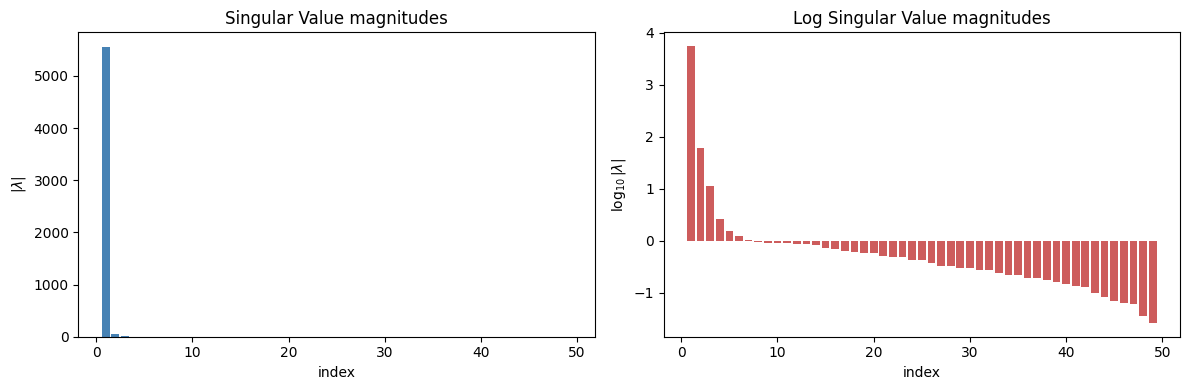

Q-function


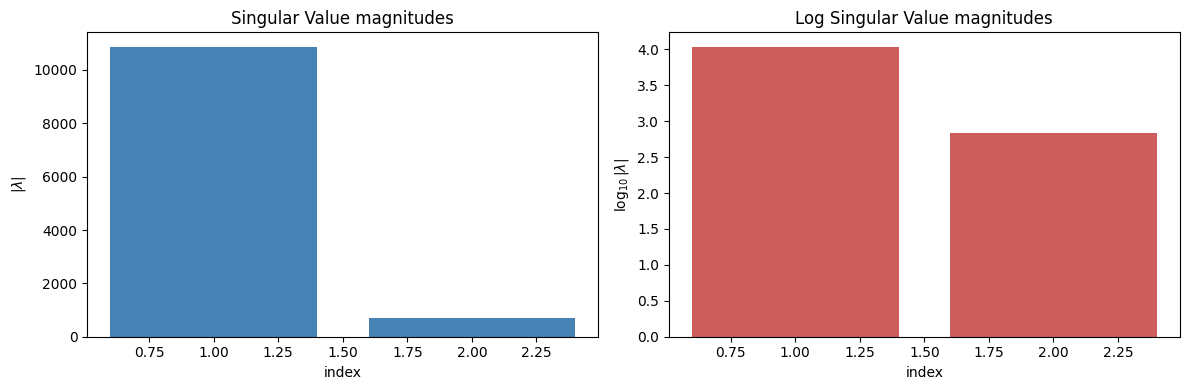

In [16]:
for method,name in zip(analysis["methods"], ['Hankel Value Function','Q-function']):
    print(name)
    matrix = method(agent=agent, env=env)
    plot_matrix_spectra(matrix)